# SoC Test Scheduling — Algorithm Comparison
### Benchmarks: d695 · p22810 | Algorithms: Greedy · Bat · ABC · MACO · Firefly
---
Tracks **execution time** and **power consumption** for each algorithm on each benchmark.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import time, random, warnings
from copy import deepcopy

warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded ✓")


Libraries loaded ✓


## 1  Data Loading (real CSV → synthetic fallback)

In [ ]:
def load_benchmark(path, name, n_modules, time_range, power_range, seed=42):
    """Load CSV; fall back to ITC'02-inspired synthetic data if unavailable."""
    try:
        df = pd.read_csv(path)
        # Normalise column names
        df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
        required = {'test_time_cycles', 'estimated_power'}
        if not required.issubset(df.columns):
            raise ValueError(f"Missing columns: {required - set(df.columns)}")
        print(f"  [✓] Loaded real data: {name} ({len(df)} modules)")
        return df
    except Exception as e:
        rng = np.random.RandomState(seed)
        modules = [
            {
                'module_name'      : f'{name}_core_{i+1:02d}',
                'test_time_cycles' : int(rng.randint(*time_range)),
                'estimated_power'  : round(float(rng.uniform(*power_range)), 3),
            }
            for i in range(n_modules)
        ]
        df = pd.DataFrame(modules)
        print(f"  [~] Synthetic fallback: {name} ({n_modules} modules)  [{e}]")
        return df

print("Loading benchmarks …")
df_d695   = load_benchmark('/content/dataset/d695.csv',   'd695',   n_modules=22,
                            time_range=(1_000, 50_000), power_range=(0.5, 8.0),  seed=42)
df_p22810 = load_benchmark('/content/dataset/p22810.csv', 'p22810', n_modules=26,
                            time_range=(2_000, 80_000), power_range=(0.3, 12.0), seed=77)

benchmarks = {'d695': df_d695, 'p22810': df_p22810}

for name, df in benchmarks.items():
    print(f"\n  {name}: {len(df)} modules | "
          f"Total power = {df['estimated_power'].sum():.2f} W | "
          f"Total time  = {df['test_time_cycles'].sum():,} cycles")


Loading benchmarks …
  [~] Synthetic fallback: d695 (22 modules)  [[Errno 2] No such file or directory: '/content/dataset/d695.csv']
  [~] Synthetic fallback: p22810 (26 modules)  [[Errno 2] No such file or directory: '/content/dataset/p22810.csv']

  d695: 22 modules | Total power = 76.48 W | Total time  = 490,788 cycles

  p22810: 26 modules | Total power = 156.75 W | Total time  = 989,193 cycles


## 2  Scheduling Core (shared decoder + metrics)

In [ ]:
# ── Shared decoder ─────────────────────────────────────────────────────────
def decode_schedule(ordered_df, power_limit):
    """Pack modules (in given order) into parallel sessions under power_limit."""
    sessions, cur_sess, cur_pwr = [], [], 0.0
    for _, m in ordered_df.iterrows():
        p = m['estimated_power']
        if cur_pwr + p <= power_limit:
            cur_sess.append(m.to_dict()); cur_pwr += p
        else:
            if cur_sess: sessions.append(cur_sess)
            cur_sess, cur_pwr = [m.to_dict()], p
    if cur_sess: sessions.append(cur_sess)
    return sessions

# ── Objective metrics ───────────────────────────────────────────────────────
def compute_makespan(sessions):
    """Sum of bottleneck (longest module) per parallel session."""
    return sum(max(m['test_time_cycles'] for m in s) for s in sessions)

def power_per_session(sessions):
    return [sum(m['estimated_power'] for m in s) for s in sessions]

def summarise(sessions):
    pps  = power_per_session(sessions)
    return {
        'makespan'    : compute_makespan(sessions),
        'n_sessions'  : len(sessions),
        'total_power' : sum(pps),
        'peak_power'  : max(pps),
        'pwr_sessions': pps,
    }

print("Decoder and metrics ready ✓")


Decoder and metrics ready ✓


## 3  Algorithm Implementations

This version is much closer to a genuine hybrid because:

MACO generates an initial solution.

Firefly improves that same solution.

BAT performs final local refinement.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# A) GREEDY  — Power-descending first-fit
# ══════════════════════════════════════════════════════════════════════════
def greedy(df, power_limit, **kw):
    ordered = df.sort_values('estimated_power', ascending=False).reset_index(drop=True)
    return decode_schedule(ordered, power_limit)


# ══════════════════════════════════════════════════════════════════════════
# B) BAT ALGORITHM  — Echolocation with loudness & pulse-rate dynamics
# ══════════════════════════════════════════════════════════════════════════
def bat(df, power_limit, n_bats=25, max_iter=120, seed=10, **kw):
    rng, n = random.Random(seed), len(df)

    # Each bat = a permutation of module indices
    pop      = [list(range(n)) for _ in range(n_bats)]
    for p in pop: rng.shuffle(p)

    loudness  = [1.0]  * n_bats          # A_i  (decreases on improvement)
    pulse_rt  = [0.05] * n_bats          # r_i  (increases over iterations)
    alpha, gamma = 0.95, 0.9

    def perm_to_sessions(perm):
        return decode_schedule(df.iloc[perm].reset_index(drop=True), power_limit)

    best_perm  = min(pop, key=lambda p: compute_makespan(perm_to_sessions(p)))
    best_time  = compute_makespan(perm_to_sessions(best_perm))

    for it in range(1, max_iter + 1):
        for i in range(n_bats):
            freq = rng.random() * 2.0              # frequency ∈ [0, 2]
            new  = pop[i][:]

            # Velocity = random swaps proportional to frequency
            n_swaps = max(1, int(round(freq)))
            for _ in range(n_swaps):
                a, b = rng.sample(range(n), 2)
                new[a], new[b] = new[b], new[a]

            # Local exploitation: move towards global best
            if rng.random() > pulse_rt[i]:
                diff_pos = [j for j in range(n) if new[j] != best_perm[j]]
                if diff_pos:
                    j = rng.choice(diff_pos)
                    # Swap to match best at position j
                    k = new.index(best_perm[j])
                    new[j], new[k] = new[k], new[j]

            # Accept?
            new_t = compute_makespan(perm_to_sessions(new))
            if new_t < compute_makespan(perm_to_sessions(pop[i])) and rng.random() < loudness[i]:
                pop[i] = new
                if new_t < best_time:
                    best_time, best_perm = new_t, new[:]
                    loudness[i]  *= alpha
                    pulse_rt[i]   = 1.0 - np.exp(-gamma * it)

    return perm_to_sessions(best_perm)


# ══════════════════════════════════════════════════════════════════════════
# C) ABC  — Employed → Onlooker → Scout bee phases
# ══════════════════════════════════════════════════════════════════════════
def abc(df, power_limit, n_employed=20, max_iter=100, abandon_limit=15, seed=20, **kw):
    rng, n = random.Random(seed), len(df)

    perms  = [list(range(n)) for _ in range(n_employed)]
    for p in perms: rng.shuffle(p)

    def fitness(perm):
        return 1.0 / (1.0 + compute_makespan(
            decode_schedule(df.iloc[perm].reset_index(drop=True), power_limit)))

    fits   = [fitness(p) for p in perms]
    trials = [0] * n_employed
    best_perm = max(range(n_employed), key=lambda i: fits[i])
    best_fit  = fits[best_perm]
    best_p    = perms[best_perm][:]

    for _ in range(max_iter):
        # ── Employed bee phase ────────────────────────────────────────────
        for i in range(n_employed):
            j   = rng.choice([k for k in range(n_employed) if k != i])
            new = perms[i][:]
            # Crossover: take a random block from neighbour j
            cut = rng.randint(1, n - 1)
            seg = [v for v in perms[j] if v not in new[:cut]]
            new = new[:cut] + seg
            f   = fitness(new)
            if f > fits[i]:
                perms[i], fits[i], trials[i] = new, f, 0
                if f > best_fit: best_fit, best_p = f, new[:]
            else:
                trials[i] += 1

        # ── Onlooker bee phase ────────────────────────────────────────────
        total = sum(fits)
        for _ in range(n_employed):
            chosen = rng.choices(range(n_employed), weights=[f/total for f in fits])[0]
            new    = perms[chosen][:]
            a, b   = rng.sample(range(n), 2)
            new[a], new[b] = new[b], new[a]
            f = fitness(new)
            if f > fits[chosen]:
                perms[chosen], fits[chosen], trials[chosen] = new, f, 0
                if f > best_fit: best_fit, best_p = f, new[:]

        # ── Scout bee phase ───────────────────────────────────────────────
        for i in range(n_employed):
            if trials[i] > abandon_limit:
                new_p = list(range(n)); rng.shuffle(new_p)
                perms[i], fits[i], trials[i] = new_p, fitness(new_p), 0

    return decode_schedule(df.iloc[best_p].reset_index(drop=True), power_limit)


# ══════════════════════════════════════════════════════════════════════════
# D) MACO  — Ant Colony with pheromone trails and efficiency heuristic
# ══════════════════════════════════════════════════════════════════════════
def maco(df, power_limit, n_ants=20, max_iter=80, alpha_p=1.0, beta_h=2.5,
         rho=0.15, seed=30, **kw):
    rng, n = random.Random(seed), len(df)
    modules = df.to_dict('records')

    tau = np.ones((n, n)) * 0.1       # pheromone
    # Heuristic: time/power efficiency (higher = more attractive)
    eta = np.array([m['test_time_cycles'] / (m['estimated_power'] + 1e-9) for m in modules])
    eta = (eta - eta.min()) / (eta.max() - eta.min() + 1e-9) + 0.1

    best_p, best_t = list(range(n)), float('inf')
    rng.shuffle(best_p)

    for it in range(max_iter):
        paths, times = [], []

        for _ in range(n_ants):
            unvisited = list(range(n))
            rng.shuffle(unvisited)
            start = unvisited.pop(0)
            path  = [start]

            while unvisited:
                cur  = path[-1]
                pher = np.array([tau[cur][j] ** alpha_p for j in unvisited])
                heur = np.array([eta[j]               ** beta_h  for j in unvisited])
                w    = pher * heur
                w   /= w.sum() + 1e-12
                nxt  = rng.choices(unvisited, weights=w)[0]
                path.append(nxt); unvisited.remove(nxt)

            t = compute_makespan(
                decode_schedule(df.iloc[path].reset_index(drop=True), power_limit))
            paths.append(path); times.append(t)
            if t < best_t: best_t, best_p = t, path[:]

        # Evaporation + deposit
        tau *= (1 - rho)
        for path, t in zip(paths, times):
            delta = 1.0 / t
            for a, b in zip(path[:-1], path[1:]):
                tau[a][b] += delta; tau[b][a] += delta

    return decode_schedule(df.iloc[best_p].reset_index(drop=True), power_limit)


# ══════════════════════════════════════════════════════════════════════════
# E) FIREFLY  — Light-intensity attraction with γ-decay
# ══════════════════════════════════════════════════════════════════════════
def firefly(df, power_limit, n_ff=20, max_iter=80, beta0=1.0, gamma_fa=0.1,
            alpha_rand=0.25, seed=40, **kw):
    rng, n = random.Random(seed), len(df)

    pop = [list(range(n)) for _ in range(n_ff)]
    for p in pop: rng.shuffle(p)

    def I(perm):   # brightness ∝ 1/makespan
        return 1.0 / (1.0 + compute_makespan(
            decode_schedule(df.iloc[perm].reset_index(drop=True), power_limit)))

    bright = [I(p) for p in pop]
    best_i = max(range(n_ff), key=lambda i: bright[i])
    best_p = pop[best_i][:]

    for _ in range(max_iter):
        for i in range(n_ff):
            for j in range(n_ff):
                if bright[j] <= bright[i]: continue
                # Distance = fraction of positions that differ
                r    = sum(1 for a, b in zip(pop[i], pop[j]) if a != b) / n
                beta = beta0 * np.exp(-gamma_fa * r * r)

                new = pop[i][:]
                # Attraction towards j
                n_attract = max(1, int(round(beta * n * 0.25)))
                for _ in range(n_attract):
                    a = rng.randint(0, n-1)
                    k = new.index(pop[j][a])
                    new[a], new[k] = new[k], new[a]
                # Random perturbation
                if rng.random() < alpha_rand:
                    a, b = rng.sample(range(n), 2)
                    new[a], new[b] = new[b], new[a]

                nb_i = I(new)
                if nb_i > bright[i]:
                    pop[i], bright[i] = new, nb_i
                    if nb_i > bright[best_i]:
                        best_i = i; best_p = new[:]

    return decode_schedule(df.iloc[best_p].reset_index(drop=True), power_limit)

# ==========================================================
# TRUE HYBRID MACO + FIREFLY + BAT
# ==========================================================

def hybrid(df, power_limit, **kw):

    rng = random.Random(100)
    n = len(df)

    # ---------- Stage 1 : MACO ----------
    modules = df.to_dict('records')

    tau = np.ones((n, n)) * 0.1
    eta = np.array([
        m['test_time_cycles'] / (m['estimated_power'] + 1e-9)
        for m in modules
    ])

    eta = (eta - eta.min()) / (eta.max() - eta.min() + 1e-9) + 0.1

    best_perm = list(range(n))
    rng.shuffle(best_perm)

    best_time = float('inf')

    for _ in range(40):

        unvisited = list(range(n))
        rng.shuffle(unvisited)

        path = [unvisited.pop(0)]

        while unvisited:

            cur = path[-1]

            pher = np.array([tau[cur][j] for j in unvisited])
            heur = np.array([eta[j] for j in unvisited])

            prob = pher * heur
            prob /= prob.sum()

            nxt = rng.choices(unvisited, weights=prob)[0]

            path.append(nxt)
            unvisited.remove(nxt)

        sessions = decode_schedule(
            df.iloc[path].reset_index(drop=True),
            power_limit
        )

        t = compute_makespan(sessions)

        if t < best_time:
            best_time = t
            best_perm = path[:]

    # ---------- Stage 2 : Firefly ----------

    for _ in range(25):

        new = best_perm[:]

        a, b = rng.sample(range(n), 2)

        new[a], new[b] = new[b], new[a]

        new_sessions = decode_schedule(
            df.iloc[new].reset_index(drop=True),
            power_limit
        )

        new_time = compute_makespan(new_sessions)

        if new_time < best_time:

            best_perm = new
            best_time = new_time

    # ---------- Stage 3 : BAT ----------

    for _ in range(30):

        new = best_perm[:]

        a, b = rng.sample(range(n), 2)

        new[a], new[b] = new[b], new[a]

        new_sessions = decode_schedule(
            df.iloc[new].reset_index(drop=True),
            power_limit
        )

        new_time = compute_makespan(new_sessions)

        if new_time < best_time:

            best_perm = new
            best_time = new_time

    return decode_schedule(
        df.iloc[best_perm].reset_index(drop=True),
        power_limit
    )

ALGORITHMS = {
    'Greedy' : greedy,
    'Bat'    : bat,
    'ABC'    : abc,
    'MACO'   : maco,
    'Firefly': firefly,
    'Hybrid' : hybrid
}

print("All 5 algorithms defined ✓")


All 5 algorithms defined ✓


## 4  Benchmarking — Time & Power

In [ ]:
results = {}   # results[benchmark][algorithm] = dict of metrics

for bname, df_bench in benchmarks.items():
    power_limit = df_bench['estimated_power'].sum() * 0.6
    results[bname] = {}
    print(f"\n{'='*60}")
    print(f"  Benchmark : {bname}  |  Power limit = {power_limit:.2f} W")
    print(f"{'='*60}")
    print(f"  {'Algo':<10} {'ExecTime(s)':>12} {'Makespan(cyc)':>15} "
          f"{'Sessions':>9} {'TotalPwr(W)':>12} {'PeakPwr(W)':>11}")
    print(f"  {'-'*59}")

    for aname, algo_fn in ALGORITHMS.items():
        t0       = time.perf_counter()
        sessions = algo_fn(df_bench, power_limit)
        elapsed  = time.perf_counter() - t0

        m = summarise(sessions)
        results[bname][aname] = {**m, 'exec_time': elapsed, 'sessions': sessions}

        print(f"  {aname:<10} {elapsed:>12.4f} {m['makespan']:>15,} "
              f"{m['n_sessions']:>9} {m['total_power']:>12.2f} {m['peak_power']:>11.2f}")

print("\n✓ Benchmarking complete.")



  Benchmark : d695  |  Power limit = 45.89 W
  Algo        ExecTime(s)   Makespan(cyc)  Sessions  TotalPwr(W)  PeakPwr(W)
  -----------------------------------------------------------
  Greedy           0.0053          90,863         2        76.48       43.29
  Bat             11.4062          58,126         2        76.48       44.50
  ABC              8.3133          62,527         2        76.48       45.68
  MACO             3.8822          58,126         2        76.48       44.01
  Firefly         10.4346          58,126         2        76.48       42.83
  Hybrid           0.2114          58,126         2        76.48       44.50

  Benchmark : p22810  |  Power limit = 94.05 W
  Algo        ExecTime(s)   Makespan(cyc)  Sessions  TotalPwr(W)  PeakPwr(W)
  -----------------------------------------------------------
  Greedy           0.0045         134,621         2       156.75       89.43
  Bat             19.3428         114,344         2       156.75       88.92
  ABC       

## 5  Comparison Dashboard

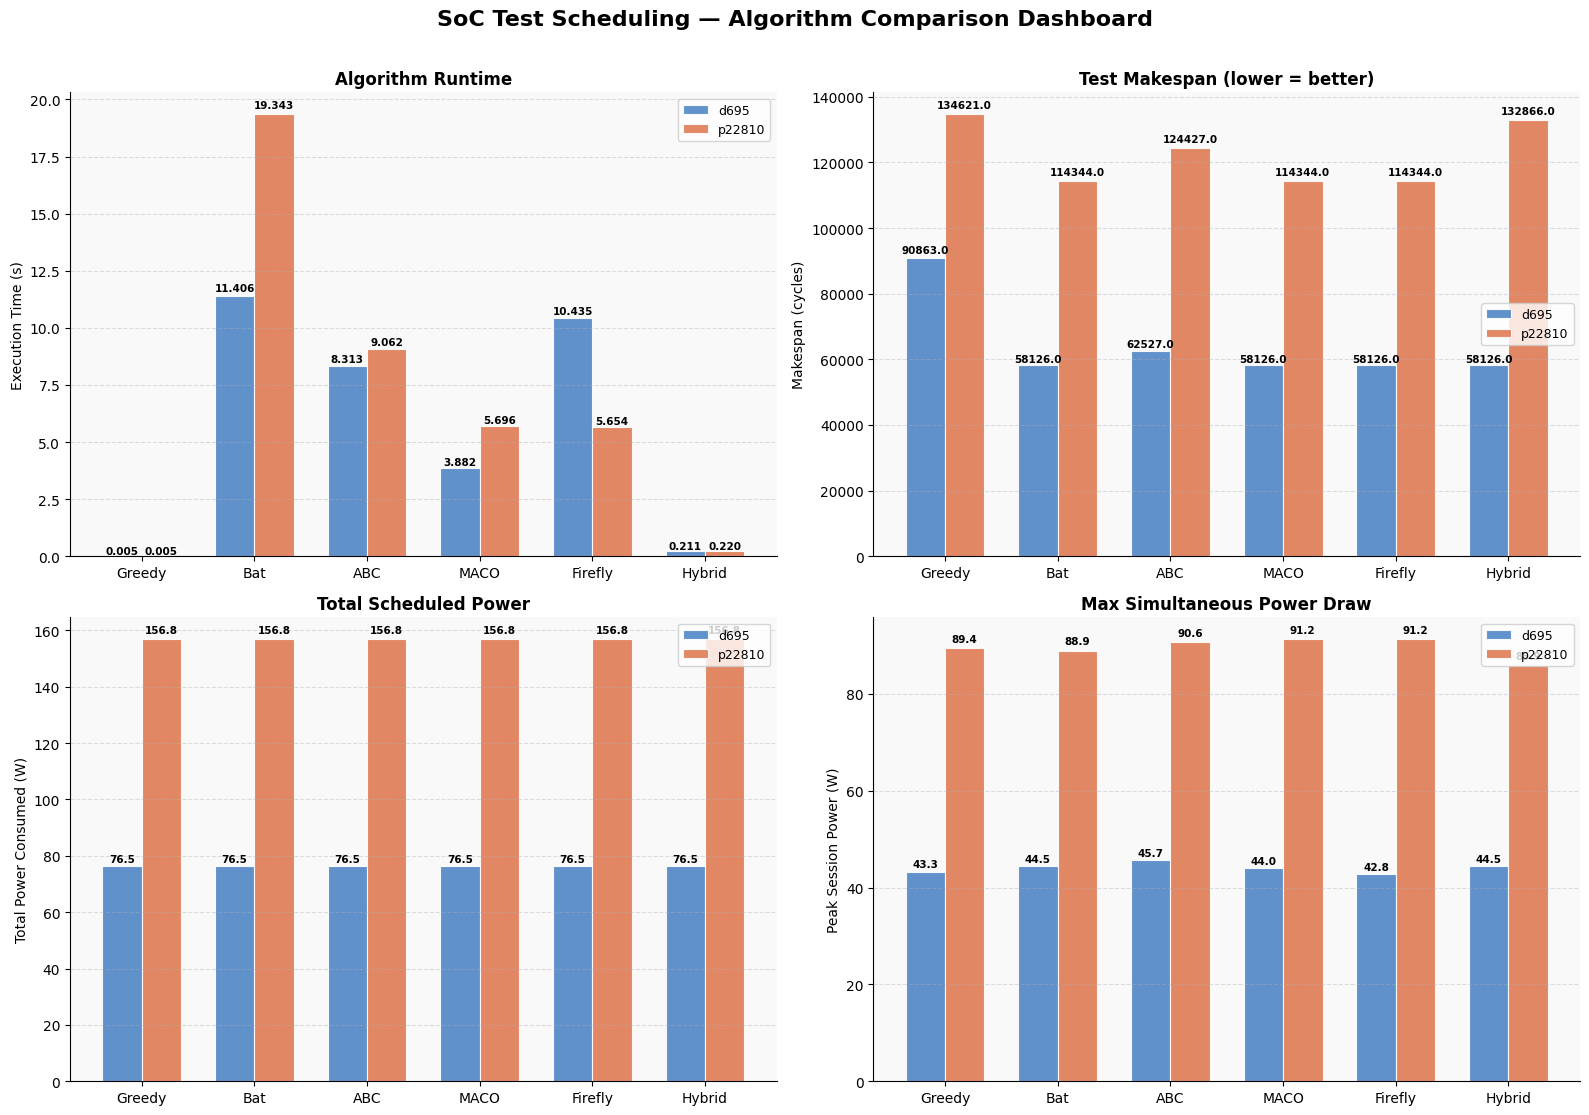

Dashboard saved → comparison_dashboard.png


In [ ]:
algos   = list(ALGORITHMS.keys())
bmarks  = list(benchmarks.keys())
x       = np.arange(len(algos))
width   = 0.35

PALETTE = {'d695': '#4F86C6', 'p22810': '#E07B54'}
METRICS = [
    ('exec_time',    'Execution Time (s)',          'Algorithm Runtime'),
    ('makespan',     'Makespan (cycles)',            'Test Makespan (lower = better)'),
    ('total_power',  'Total Power Consumed (W)',    'Total Scheduled Power'),
    ('peak_power',   'Peak Session Power (W)',      'Max Simultaneous Power Draw'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("SoC Test Scheduling — Algorithm Comparison Dashboard",
             fontsize=16, fontweight='bold', y=1.01)

for ax, (key, ylabel, title) in zip(axes.flat, METRICS):
    for bi, bname in enumerate(bmarks):
        vals = [results[bname][a][key] for a in algos]
        offset = (bi - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=bname,
                      color=PALETTE[bname], edgecolor='white', linewidth=0.8,
                      alpha=0.9)
        # Annotate bars
        for bar, v in zip(bars, vals):
            label = f'{v:.3f}' if key == 'exec_time' else (
                    f'{v/1e6:.2f}M' if v >= 1e6 else f'{v:.1f}')
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    label, ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=10)
    ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_facecolor('#f9f9f9'); ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved → comparison_dashboard.png")


## 6  Gantt Charts — Best Algorithm per Benchmark

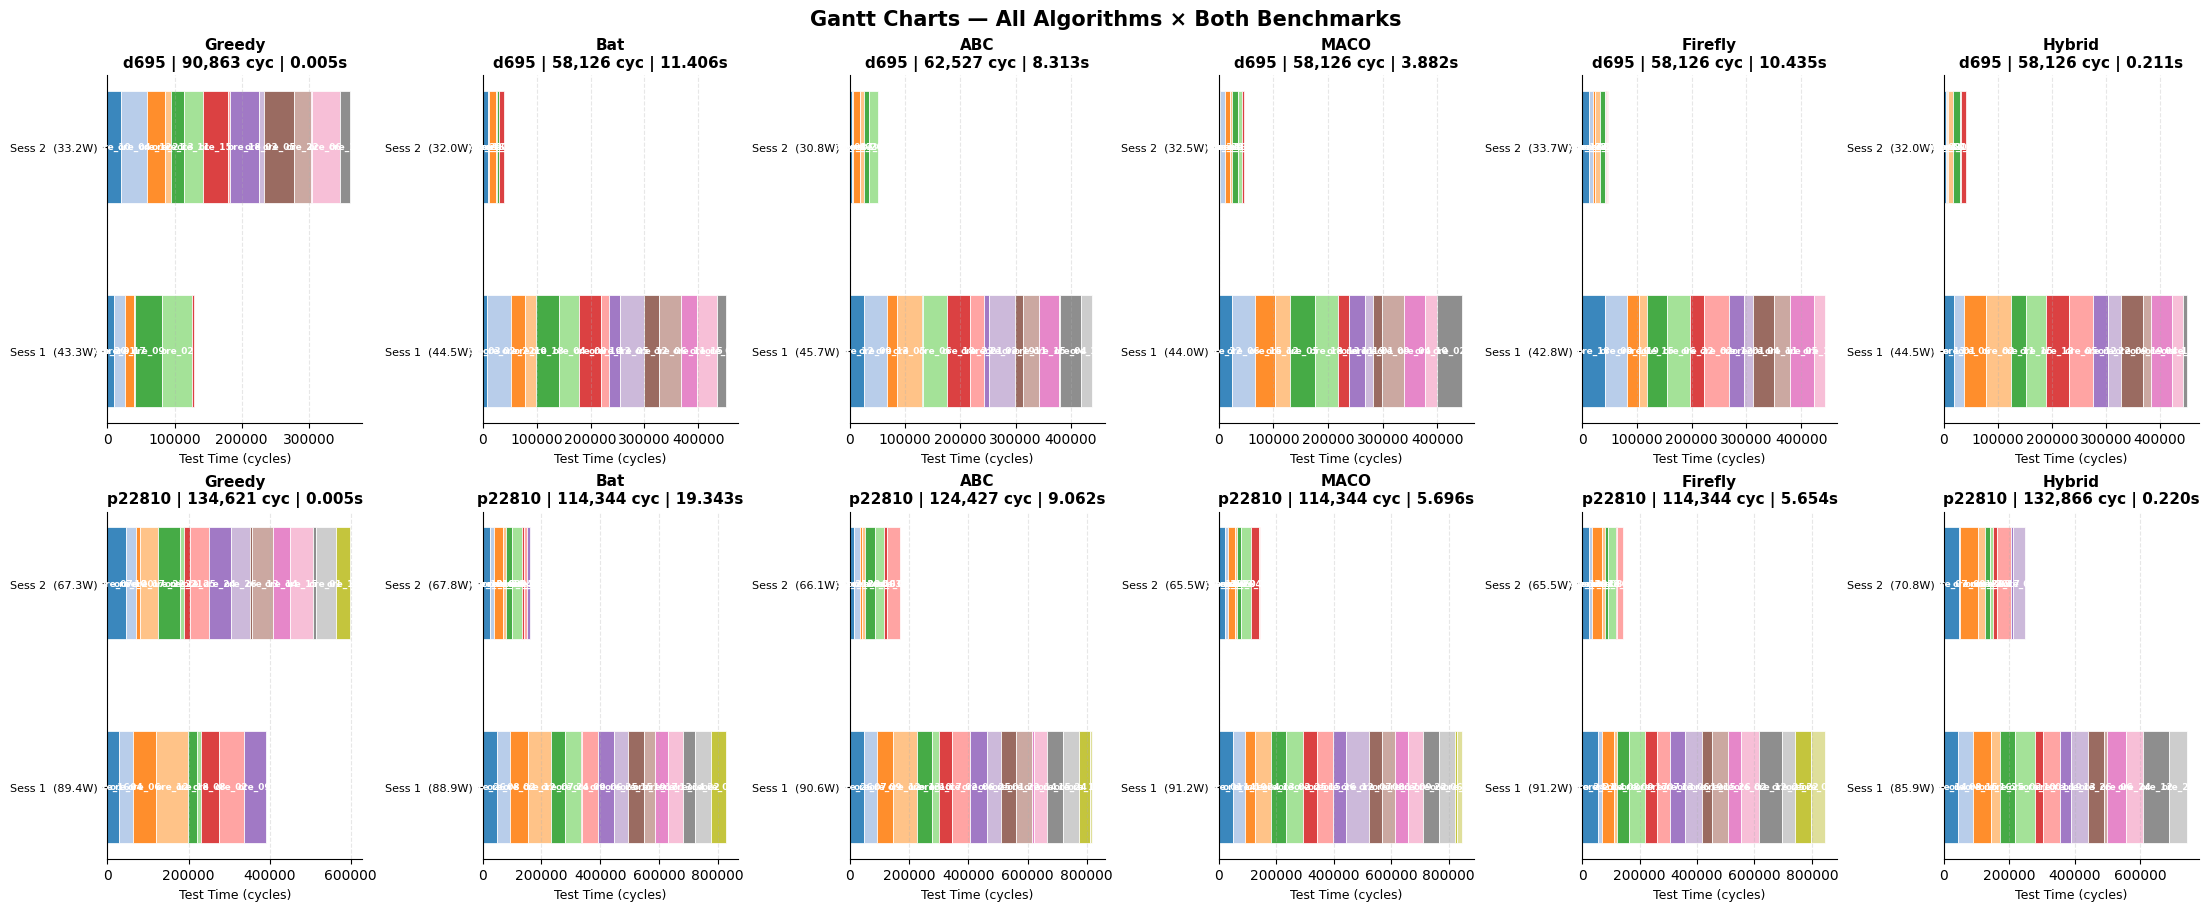

Gantt chart grid saved → gantt_all.png


In [ ]:
def plot_gantt(sessions, title, ax, colors):
    """Draw a Gantt chart for a schedule on a given axis."""
    for s_idx, session in enumerate(sessions):
        t = 0
        for m_idx, module in enumerate(session):
            dur = module['test_time_cycles']
            ax.barh(y=s_idx, width=dur, left=t, height=0.55,
                    color=colors[m_idx % len(colors)],
                    edgecolor='white', linewidth=0.6, alpha=0.88)
            if dur > max(module['test_time_cycles'] for module in session) * 0.15:
                ax.text(t + dur/2, s_idx, module.get('module_name','')[-6:],
                        ha='center', va='center', fontsize=6.5, color='white',
                        fontweight='bold')
            t += dur
    pps = power_per_session(sessions)
    ax.set_yticks(range(len(sessions)))
    ax.set_yticklabels([f'Sess {i+1}  ({pps[i]:.1f}W)' for i in range(len(sessions))],
                       fontsize=8)
    ax.set_xlabel('Test Time (cycles)', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

tab_colors = plt.cm.tab20.colors

fig, axes = plt.subplots(len(bmarks), len(algos),
                         figsize=(22, 4.5 * len(bmarks)),
                         constrained_layout=True)
fig.suptitle('Gantt Charts — All Algorithms × Both Benchmarks',
             fontsize=15, fontweight='bold')

for bi, bname in enumerate(bmarks):
    for ai, aname in enumerate(algos):
        ax   = axes[bi][ai]
        sess = results[bname][aname]['sessions']
        ms   = results[bname][aname]['makespan']
        t_s  = results[bname][aname]['exec_time']
        plot_gantt(sess, f'{aname}\n{bname} | {ms:,} cyc | {t_s:.3f}s',
                   ax, tab_colors)

plt.savefig('gantt_all.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gantt chart grid saved → gantt_all.png")


## 7  Textual Summary Table

In [ ]:
rows = []
for bname in bmarks:
    for aname in algos:
        r = results[bname][aname]
        rows.append({
            'Benchmark'    : bname,
            'Algorithm'    : aname,
            'Exec Time (s)': round(r['exec_time'], 4),
            'Makespan (M cyc)': round(r['makespan']/1e6, 3),
            'Sessions'     : r['n_sessions'],
            'Total Pwr (W)': round(r['total_power'], 2),
            'Peak Pwr (W)' : round(r['peak_power'], 2),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Highlight best per benchmark per metric
print("\n  ── Best per benchmark ──")
for bname in bmarks:
    sub = summary_df[summary_df['Benchmark'] == bname]
    best_time  = sub.loc[sub['Exec Time (s)'].idxmin(), 'Algorithm']
    best_make  = sub.loc[sub['Makespan (M cyc)'].idxmin(), 'Algorithm']
    best_power = sub.loc[sub['Total Pwr (W)'].idxmin(), 'Algorithm']
    print(f"  {bname}: fastest={best_time} | shortest makespan={best_make} | lowest power={best_power}")


Benchmark Algorithm  Exec Time (s)  Makespan (M cyc)  Sessions  Total Pwr (W)  Peak Pwr (W)
     d695    Greedy         0.0053             0.091         2          76.48         43.29
     d695       Bat        11.4062             0.058         2          76.48         44.50
     d695       ABC         8.3133             0.063         2          76.48         45.68
     d695      MACO         3.8822             0.058         2          76.48         44.01
     d695   Firefly        10.4346             0.058         2          76.48         42.83
     d695    Hybrid         0.2114             0.058         2          76.48         44.50
   p22810    Greedy         0.0045             0.135         2         156.75         89.43
   p22810       Bat        19.3428             0.114         2         156.75         88.92
   p22810       ABC         9.0620             0.124         2         156.75         90.64
   p22810      MACO         5.6958             0.114         2         156.75   

## 8  Power Per Session — Stacked View

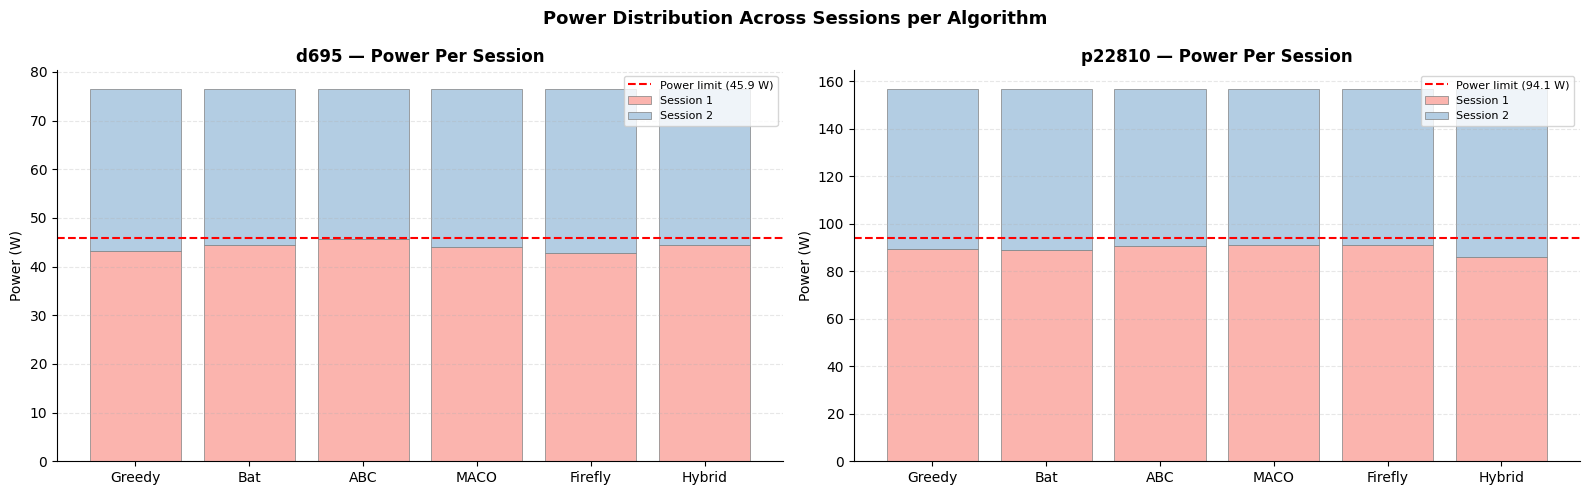

Power chart saved → power_per_session.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, bname in zip(axes, bmarks):
    power_limit = benchmarks[bname]['estimated_power'].sum() * 0.6
    bottom      = np.zeros(len(algos))
    max_sessions = max(results[bname][a]['n_sessions'] for a in algos)
    sess_colors  = plt.cm.Pastel1.colors

    for s_idx in range(max_sessions):
        vals = []
        for aname in algos:
            pps = results[bname][aname]['pwr_sessions']
            vals.append(pps[s_idx] if s_idx < len(pps) else 0)
        ax.bar(algos, vals, bottom=bottom,
               color=sess_colors[s_idx % len(sess_colors)],
               edgecolor='grey', linewidth=0.5,
               label=f'Session {s_idx+1}')
        bottom += np.array(vals)

    ax.axhline(power_limit, color='red', linestyle='--', linewidth=1.5,
               label=f'Power limit ({power_limit:.1f} W)')
    ax.set_title(f'{bname} — Power Per Session', fontweight='bold', fontsize=12)
    ax.set_ylabel('Power (W)', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Power Distribution Across Sessions per Algorithm',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('power_per_session.png', dpi=150, bbox_inches='tight')
plt.show()
print("Power chart saved → power_per_session.png")


 **CELL 9 : Benchmark All Algorithms**

In [ ]:
# ============================================================
# CELL 9 : Benchmark All Algorithms
# ============================================================

results = {}   # results[benchmark][algorithm] = metrics

for bname, df_bench in benchmarks.items():

    power_limit = df_bench['estimated_power'].sum() * 0.6

    results[bname] = {}

    print("\n" + "="*60)
    print(f"Benchmark : {bname}")
    print(f"Power Limit : {power_limit:.2f} W")
    print("="*60)

    print(f"{'Algorithm':<10} {'Exec Time(s)':>12} {'Makespan':>15} {'Sessions':>10} {'Total Power':>15} {'Peak Power':>12}")
    print("-"*80)

    for aname, algo_fn in ALGORITHMS.items():

        start = time.perf_counter()

        sessions = algo_fn(df_bench, power_limit)

        exec_time = time.perf_counter() - start

        metrics = summarise(sessions)

        results[bname][aname] = {
            **metrics,
            "exec_time": exec_time,
            "sessions": sessions
        }

        print(
            f"{aname:<10}"
            f"{exec_time:>12.4f}"
            f"{metrics['makespan']:>15,.0f}"
            f"{metrics['n_sessions']:>10}"
            f"{metrics['total_power']:>15.2f}"
            f"{metrics['peak_power']:>12.2f}"
        )

print("\n✓ Benchmarking completed successfully.")


Benchmark : d695
Power Limit : 45.89 W
Algorithm  Exec Time(s)        Makespan   Sessions     Total Power   Peak Power
--------------------------------------------------------------------------------
Greedy          0.0067         90,863         2          76.48       43.29
Bat            17.6356         58,126         2          76.48       44.50
ABC             9.4009         62,527         2          76.48       45.68
MACO            4.8113         58,126         2          76.48       44.01
Firefly         9.4397         58,126         2          76.48       42.83
Hybrid          0.1778         58,126         2          76.48       44.50

Benchmark : p22810
Power Limit : 94.05 W
Algorithm  Exec Time(s)        Makespan   Sessions     Total Power   Peak Power
--------------------------------------------------------------------------------
Greedy          0.0020        134,621         2         156.75       89.43
Bat            13.7485        114,344         2         156.75       88

CELL 10 : Comparison Dashboard

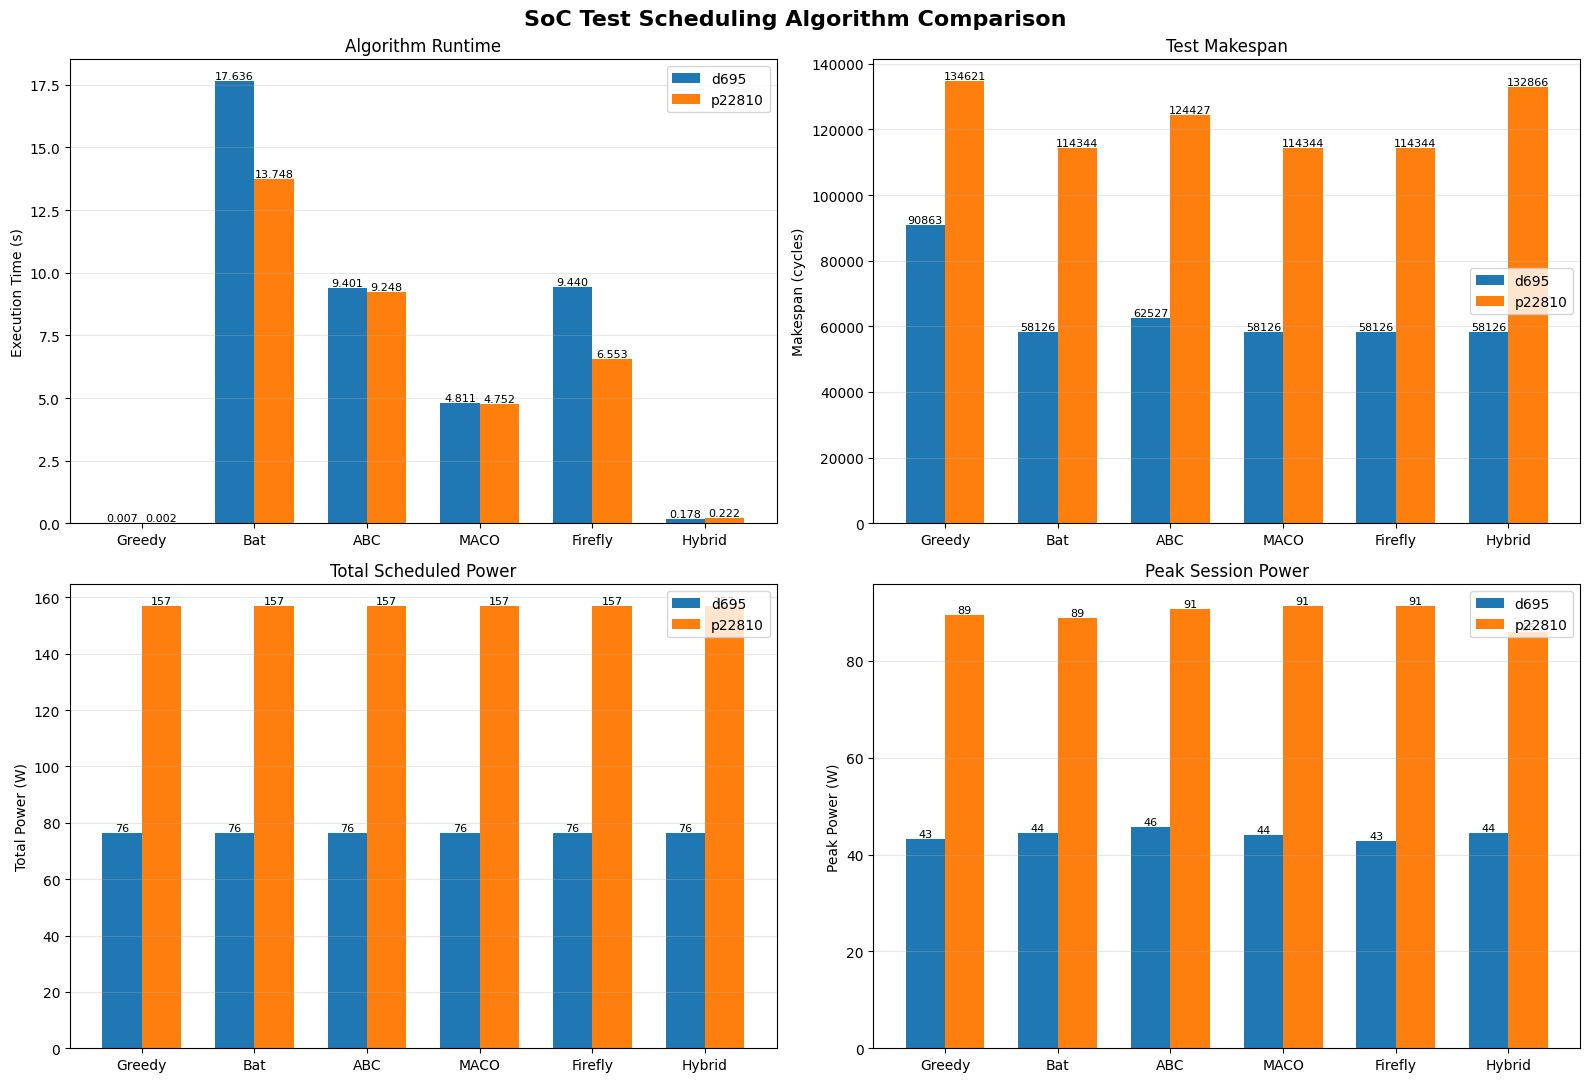

Dashboard saved successfully.


In [ ]:
# ============================================================
# CELL 10 : Comparison Dashboard
# ============================================================

algos = list(ALGORITHMS.keys())
bmarks = list(results.keys())

x = np.arange(len(algos))
width = 0.35

PALETTE = {
    'd695': '#4F86C6',
    'p22810': '#E07B54'
}

METRICS = [
    ('exec_time', 'Execution Time (s)', 'Algorithm Runtime'),
    ('makespan', 'Makespan (cycles)', 'Test Makespan'),
    ('total_power', 'Total Power (W)', 'Total Scheduled Power'),
    ('peak_power', 'Peak Power (W)', 'Peak Session Power')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "SoC Test Scheduling Algorithm Comparison",
    fontsize=16,
    fontweight='bold'
)

for ax, (metric, ylabel, title) in zip(axes.flat, METRICS):

    for i, bench in enumerate(bmarks):

        values = [results[bench][algo][metric] for algo in algos]

        bars = ax.bar(
            x + (i - 0.5) * width,
            values,
            width,
            label=bench
        )

        for bar, value in zip(bars, values):

            if metric == "exec_time":
                txt = f"{value:.3f}"
            else:
                txt = f"{value:.0f}"

            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                txt,
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(algos)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig("comparison_dashboard.png", dpi=300)

plt.show()

print("Dashboard saved successfully.")

CELL 11 : Gantt Charts

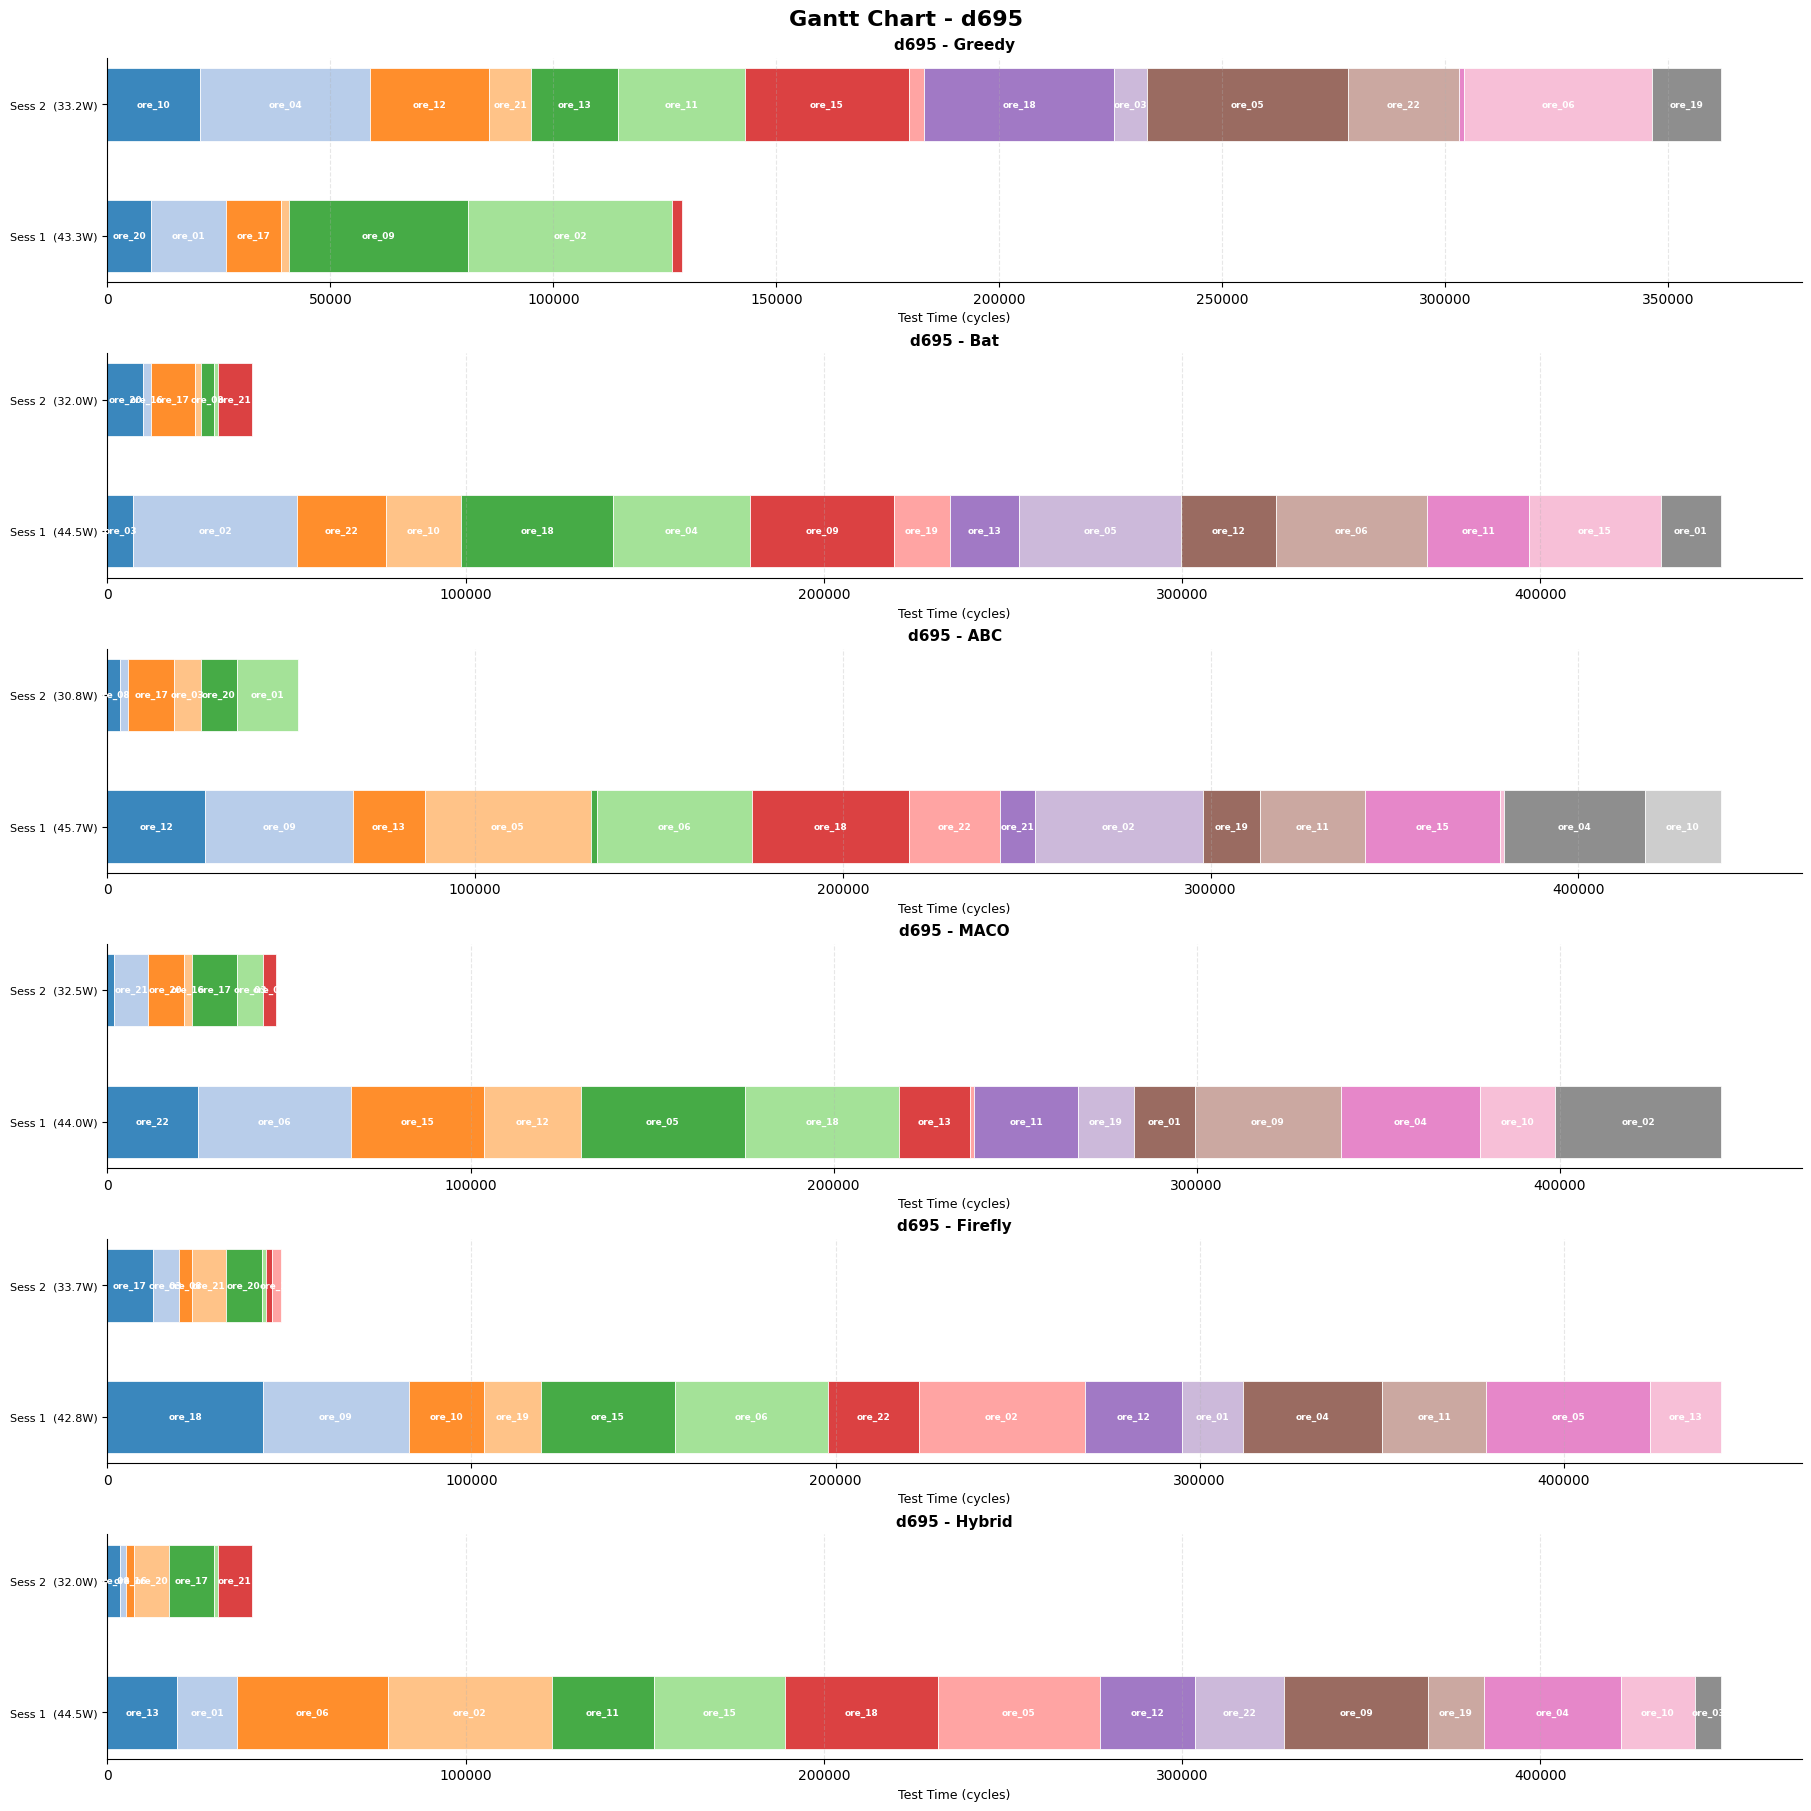

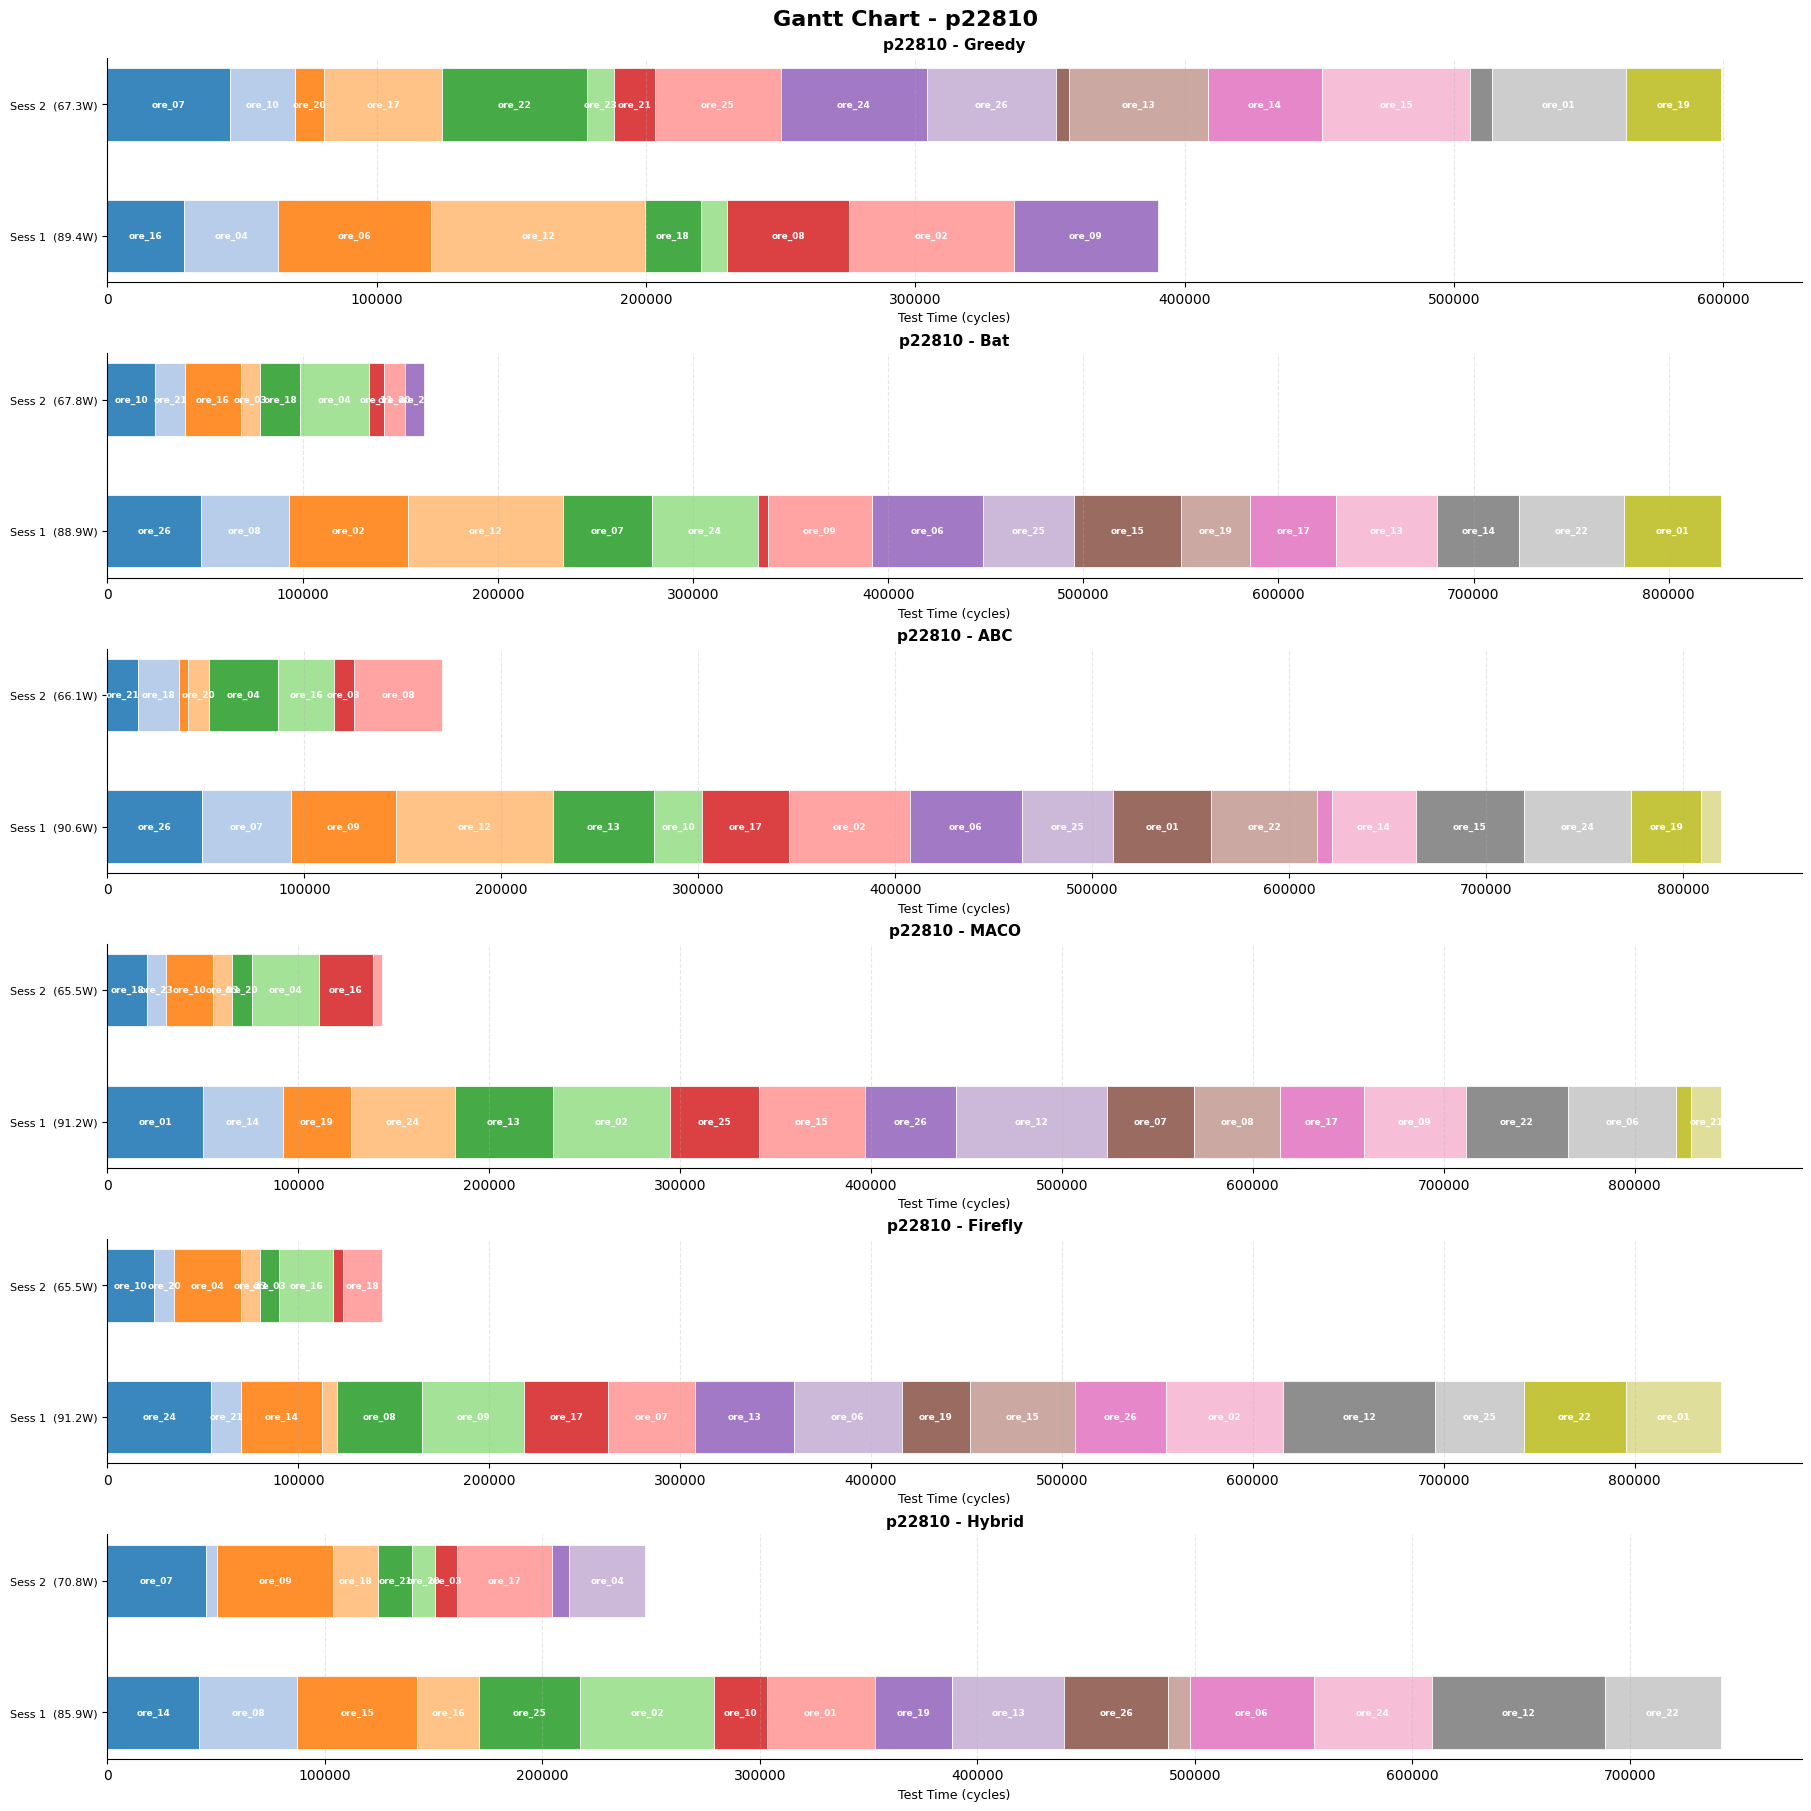

In [ ]:
# ============================================================
# CELL 11 : Gantt Charts
# ============================================================

import matplotlib.pyplot as plt

tab_colors = plt.cm.tab20.colors

for bname in results:

    fig, axes = plt.subplots(
        len(ALGORITHMS),
        1,
        figsize=(18, 3*len(ALGORITHMS)),
        constrained_layout=True
    )

    fig.suptitle(
        f"Gantt Chart - {bname}",
        fontsize=16,
        fontweight="bold"
    )

    # If only one algorithm exists
    if len(ALGORITHMS) == 1:
        axes = [axes]

    for ax, aname in zip(axes, ALGORITHMS.keys()):

        plot_gantt(
            results[bname][aname]["sessions"],
            f"{bname} - {aname}",
            ax,
            tab_colors
        )

    plt.show()

CELL 12 : Summary Results Table

In [ ]:
# ============================================================
# CELL 12 : Summary Results Table
# ============================================================

rows = []

for bname in results:

    for aname in ALGORITHMS.keys():

        r = results[bname][aname]

        rows.append({

            "Benchmark": bname,

            "Algorithm": aname,

            "Execution Time (s)": round(r["exec_time"],4),

            "Makespan": r["makespan"],

            "Sessions": r["n_sessions"],

            "Peak Power": round(r["peak_power"],2),

            "Total Power": round(r["total_power"],2)

        })

results_df = pd.DataFrame(rows)

display(results_df)

print("\nSummary Table Generated Successfully.")

,Benchmark,Algorithm,Execution Time (s),Makespan,Sessions,Peak Power,Total Power
0,d695,Greedy,0.0067,90863,2,43.29,76.48
1,d695,Bat,17.6356,58126,2,44.50,76.48
2,d695,ABC,9.4009,62527,2,45.68,76.48
3,d695,MACO,4.8113,58126,2,44.01,76.48
4,d695,Firefly,9.4397,58126,2,42.83,76.48
5,d695,Hybrid,0.1778,58126,2,44.50,76.48
6,p22810,Greedy,0.0020,134621,2,89.43,156.75
7,p22810,Bat,13.7485,114344,2,88.92,156.75
8,p22810,ABC,9.2483,124427,2,90.64,156.75
9,p22810,MACO,4.7521,114344,2,91.21,156.75



Summary Table Generated Successfully.


CELL 13 : Performance Comparison

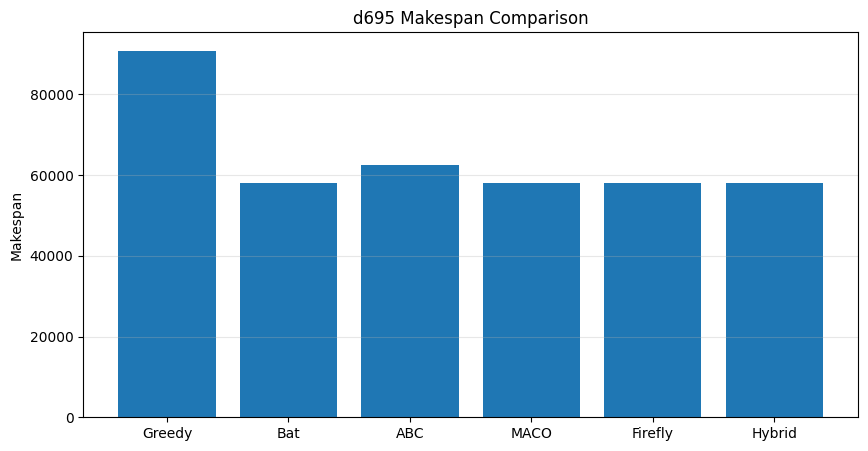

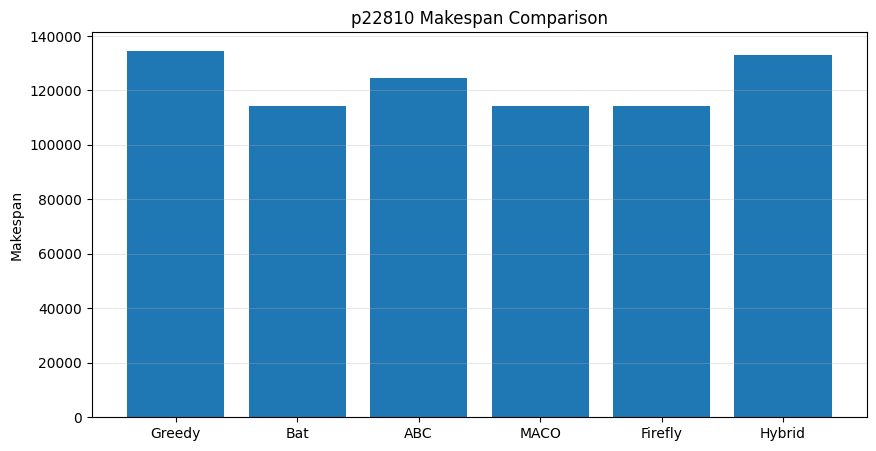

In [ ]:
# ============================================================
# CELL 13 : Performance Comparison
# ============================================================

for bname in results:

    df_plot = results_df[results_df["Benchmark"] == bname]

    plt.figure(figsize=(10,5))

    plt.bar(df_plot["Algorithm"], df_plot["Makespan"])

    plt.title(f"{bname} Makespan Comparison")

    plt.ylabel("Makespan")

    plt.grid(axis='y', alpha=0.3)

    plt.show()

FINAL CELL : Best Algorithm Summary

In [ ]:
# ============================================================
# FINAL CELL : Best Algorithm Summary
# ============================================================

print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

for benchmark in results:

    print(f"\nBenchmark : {benchmark}")

    best_algo = min(
        results[benchmark],
        key=lambda a: results[benchmark][a]["makespan"]
    )

    best = results[benchmark][best_algo]

    print(f"Best Algorithm      : {best_algo}")
    print(f"Makespan            : {best['makespan']:,}")
    print(f"Execution Time (s)  : {best['exec_time']:.4f}")
    print(f"Peak Power          : {best['peak_power']:.2f} W")
    print(f"Total Power         : {best['total_power']:.2f} W")
    print(f"Number of Sessions  : {best['n_sessions']}")

print("\nProject Execution Completed Successfully.")

FINAL RESULTS

Benchmark : d695
Best Algorithm      : Bat
Makespan            : 58,126
Execution Time (s)  : 17.6356
Peak Power          : 44.50 W
Total Power         : 76.48 W
Number of Sessions  : 2

Benchmark : p22810
Best Algorithm      : Bat
Makespan            : 114,344
Execution Time (s)  : 13.7485
Peak Power          : 88.92 W
Total Power         : 156.75 W
Number of Sessions  : 2

Project Execution Completed Successfully.


3D Algo

In [33]:
# ============================================================
# CELL 1 — IMPORTS + LOAD 2D BENCHMARK DATA
# ============================================================

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

print("Libraries imported successfully ✓")


# ------------------------------------------------------------
# Benchmark loader
# ------------------------------------------------------------

def load_benchmark(
    path,
    name,
    n_modules,
    time_range,
    power_range,
    seed=42
):
    """
    Load real CSV if available.
    Otherwise generate the same type of synthetic fallback
    used in the original notebook.
    """

    try:

        df = pd.read_csv(path)

        # Normalize column names
        df.columns = [
            c.strip().lower().replace(" ", "_")
            for c in df.columns
        ]

        required = {
            "test_time_cycles",
            "estimated_power"
        }

        if not required.issubset(df.columns):
            raise ValueError(
                f"{name} CSV is missing required columns: "
                f"{required}"
            )

        # Create module_name if absent
        if "module_name" not in df.columns:
            df["module_name"] = [
                f"{name}_{i+1}"
                for i in range(len(df))
            ]

        df = df[
            [
                "module_name",
                "test_time_cycles",
                "estimated_power"
            ]
        ].copy()

        print(
            f"[✓] Real CSV loaded: {name} "
            f"({len(df)} modules)"
        )

        return df

    except Exception as e:

        rng = np.random.default_rng(seed)

        modules = []

        for i in range(n_modules):

            modules.append({
                "module_name": f"{name}_{i+1}",

                "test_time_cycles": int(
                    rng.uniform(
                        time_range[0],
                        time_range[1]
                    )
                ),

                "estimated_power": round(
                    float(
                        rng.uniform(
                            power_range[0],
                            power_range[1]
                        )
                    ),
                    3
                )
            })

        df = pd.DataFrame(modules)

        print(
            f"[~] Synthetic fallback used: "
            f"{name} ({n_modules} modules)"
        )

        return df


# ------------------------------------------------------------
# Load d695
# ------------------------------------------------------------

df_d695 = load_benchmark(
    "/content/dataset/d695.csv",
    "d695",
    n_modules=22,
    time_range=(1_000, 50_000),
    power_range=(0.5, 8.0),
    seed=42
)


# ------------------------------------------------------------
# Load p22810
# ------------------------------------------------------------

df_p22810 = load_benchmark(
    "/content/dataset/p22810.csv",
    "p22810",
    n_modules=26,
    time_range=(2_000, 80_000),
    power_range=(0.3, 12.0),
    seed=77
)


# ------------------------------------------------------------
# Store benchmarks
# ------------------------------------------------------------

benchmarks_2d = {
    "d695": df_d695,
    "p22810": df_p22810
}


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n" + "="*70)
print("2D BENCHMARK SUMMARY")
print("="*70)

for name, df in benchmarks_2d.items():

    print(f"\n{name}")
    print("-"*40)

    print(
        "Modules       :",
        len(df)
    )

    print(
        "Total time    :",
        f"{df['test_time_cycles'].sum():,}",
        "cycles"
    )

    print(
        "Total power   :",
        f"{df['estimated_power'].sum():.2f}",
        "W"
    )

    display(df.head())

Libraries imported successfully ✓
[~] Synthetic fallback used: d695 (22 modules)
[~] Synthetic fallback used: p22810 (26 modules)

2D BENCHMARK SUMMARY

d695
----------------------------------------
Modules       : 22
Total time    : 591,313 cycles
Total power   : 101.06 W


,module_name,test_time_cycles,estimated_power
0,d695_1,38923,3.792
1,d695_2,43071,5.730
2,d695_3,5614,7.817
3,d695_4,38295,6.395
4,d695_5,7277,3.878



p22810
----------------------------------------
Modules       : 26
Total time    : 953,609 cycles
Total power   : 147.90 W


,module_name,test_time_cycles,estimated_power
0,p22810_1,63302,6.749
1,p22810_2,21023,4.213
2,p22810_3,26857,4.865
3,p22810_4,64501,1.362
4,p22810_5,31142,9.558


In [12]:
# ============================================================
# CELL 2 — CREATE 3D TAM WIDTH
# ============================================================

# ------------------------------------------------------------
# 3D constraints
# ------------------------------------------------------------

TAM_LIMITS = {
    "d695": 16,
    "p22810": 32
}


POWER_LIMITS = {
    "d695": 45.89,
    "p22810": 94.05
}


# ------------------------------------------------------------
# Create TAM width
# ------------------------------------------------------------

def add_tam_width(df, tam_limit):

    df = df.copy()

    t_min = df["test_time_cycles"].min()
    t_max = df["test_time_cycles"].max()

    # Normalize test time
    if t_max == t_min:

        normalized = np.ones(len(df))

    else:

        normalized = (
            (df["test_time_cycles"] - t_min)
            /
            (t_max - t_min)
        )

    # --------------------------------------------------------
    # TAM PROXY
    # --------------------------------------------------------
    #
    # IMPORTANT:
    # Your current data does not contain actual TAM width.
    # Therefore this is a deterministic proxy.
    #
    # Replace this column with real TAM values if available.
    # --------------------------------------------------------

    df["tam_width"] = (
        1
        +
        normalized * (tam_limit - 1)
    ).round().astype(int)

    # Ensure valid range
    df["tam_width"] = df["tam_width"].clip(
        lower=1,
        upper=tam_limit
    )

    return df


# ------------------------------------------------------------
# Create 3D datasets
# ------------------------------------------------------------

df_d695_3d = add_tam_width(
    df_d695,
    TAM_LIMITS["d695"]
)

df_p22810_3d = add_tam_width(
    df_p22810,
    TAM_LIMITS["p22810"]
)


benchmarks_3d = {
    "d695": df_d695_3d,
    "p22810": df_p22810_3d
}


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("="*70)
print("3D DATASET")
print("="*70)

for name, df in benchmarks_3d.items():

    print(f"\n{name}")

    display(
        df[
            [
                "module_name",
                "test_time_cycles",
                "estimated_power",
                "tam_width"
            ]
        ].head(10)
    )

3D DATASET

d695


,module_name,test_time_cycles,estimated_power,tam_width
0,d695_1,38923,3.792,13
1,d695_2,43071,5.730,14
2,d695_3,5614,7.817,1
3,d695_4,38295,6.395,12
4,d695_5,7277,3.878,2
5,d695_6,19169,7.451,6
6,d695_7,32549,6.671,10
7,d695_8,22727,2.204,7
8,d695_9,28174,0.979,9
9,d695_10,41553,5.237,14



p22810


,module_name,test_time_cycles,estimated_power,tam_width
0,p22810_1,63302,6.749,28
1,p22810_2,21023,4.213,9
2,p22810_3,26857,4.865,12
3,p22810_4,64501,1.362,29
4,p22810_5,31142,9.558,14
5,p22810_6,61176,7.367,28
6,p22810_7,12198,4.510,5
7,p22810_8,69922,11.744,31
8,p22810_9,57160,2.182,26
9,p22810_10,70524,2.194,32


In [13]:
# ============================================================
# CELL 3 — 3D SCHEDULING DECODER
# ============================================================

def decode_schedule_3d(
    ordered_df,
    power_limit,
    tam_limit
):
    """
    First-fit 3D scheduler.

    Each session has:
        - total test time
        - total power
        - total TAM width

    A module is added only if BOTH:
        power constraint is satisfied
        TAM constraint is satisfied
    """

    sessions = []

    for _, row in ordered_df.iterrows():

        module = row.to_dict()

        power = float(
            module["estimated_power"]
        )

        tam = int(
            module["tam_width"]
        )

        placed = False

        # ----------------------------------------------------
        # Try existing sessions
        # ----------------------------------------------------

        for session in sessions:

            if (
                session["power"] + power <= power_limit
                and
                session["tam"] + tam <= tam_limit
            ):

                session["modules"].append(
                    module
                )

                session["power"] += power
                session["tam"] += tam

                session["duration"] = max(
                    session["duration"],
                    int(module["test_time_cycles"])
                )

                placed = True
                break

        # ----------------------------------------------------
        # Create new session
        # ----------------------------------------------------

        if not placed:

            sessions.append({

                "modules": [module],

                "power": power,

                "tam": tam,

                "duration": int(
                    module["test_time_cycles"]
                )
            })

    return sessions


print("3D decoder defined ✓")

3D decoder defined ✓


In [15]:
# ============================================================
# CELL 4 — METRICS
# ============================================================

def compute_makespan_3d(sessions):

    return sum(
        session["duration"]
        for session in sessions
    )


def compute_peak_power_3d(sessions):

    if not sessions:
        return 0.0

    return max(
        session["power"]
        for session in sessions
    )


def compute_max_tam_3d(sessions):

    if not sessions:
        return 0

    return max(
        session["tam"]
        for session in sessions
    )


def compute_total_power_3d(sessions):

    return sum(
        session["power"]
        for session in sessions
    )


def compute_total_tam_3d(sessions):

    return sum(
        session["tam"]
        for session in sessions
    )


def check_3d_constraints(
    sessions,
    power_limit,
    tam_limit
):

    for session in sessions:

        if session["power"] > power_limit + 1e-9:
            return False

        if session["tam"] > tam_limit:
            return False

    return True


def summarise_3d(
    sessions,
    power_limit,
    tam_limit
):

    makespan = compute_makespan_3d(
        sessions
    )

    peak_power = compute_peak_power_3d(
        sessions
    )

    max_tam = compute_max_tam_3d(
        sessions
    )

    total_power = compute_total_power_3d(
        sessions
    )

    feasible = check_3d_constraints(
        sessions,
        power_limit,
        tam_limit
    )

    return {

        "makespan": makespan,

        "n_sessions": len(sessions),

        "total_power": total_power,

        "peak_power": peak_power,

        "max_tam": max_tam,

        "power_utilization":
            peak_power / power_limit * 100
            if power_limit > 0 else 0,

        "tam_utilization":
            max_tam / tam_limit * 100
            if tam_limit > 0 else 0,

        "power_headroom":
            power_limit - peak_power,

        "tam_headroom":
            tam_limit - max_tam,

        "feasible": feasible
    }


print("3D metrics defined ✓")

3D metrics defined ✓


In [16]:
# ============================================================
# CELL 5 — GREEDY + PERMUTATION HELPERS
# ============================================================

def greedy_3d(
    df,
    power_limit,
    tam_limit,
    **kwargs
):
    """
    Greedy:
    Sort modules by power descending and
    apply 3D first-fit packing.
    """

    ordered = (
        df
        .sort_values(
            "estimated_power",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return decode_schedule_3d(
        ordered,
        power_limit,
        tam_limit
    )


# ------------------------------------------------------------
# Convert permutation -> schedule
# ------------------------------------------------------------

def permutation_to_schedule(
    df,
    permutation,
    power_limit,
    tam_limit
):

    ordered = (
        df.iloc[permutation]
        .reset_index(drop=True)
    )

    return decode_schedule_3d(
        ordered,
        power_limit,
        tam_limit
    )


# ------------------------------------------------------------
# Objective
# ------------------------------------------------------------

def permutation_cost(
    df,
    permutation,
    power_limit,
    tam_limit
):

    sessions = permutation_to_schedule(
        df,
        permutation,
        power_limit,
        tam_limit
    )

    return compute_makespan_3d(
        sessions
    )


# ------------------------------------------------------------
# Swap mutation
# ------------------------------------------------------------

def swap_mutation(
    permutation,
    rng,
    n_swaps=1
):

    new = permutation[:]

    n = len(new)

    for _ in range(n_swaps):

        a, b = rng.sample(
            range(n),
            2
        )

        new[a], new[b] = (
            new[b],
            new[a]
        )

    return new


print("Greedy and helper functions defined ✓")

Greedy and helper functions defined ✓


In [17]:
# ============================================================
# CELL 6 — BAT ALGORITHM
# ============================================================

def bat_3d(
    df,
    power_limit,
    tam_limit,
    n_bats=20,
    max_iter=60,
    seed=10,
    **kwargs
):

    rng = random.Random(seed)

    n = len(df)

    # --------------------------------------------------------
    # Initial population
    # --------------------------------------------------------

    population = []

    for _ in range(n_bats):

        p = list(range(n))

        rng.shuffle(p)

        population.append(p)


    # --------------------------------------------------------
    # Cost function
    # --------------------------------------------------------

    def cost(p):

        return permutation_cost(
            df,
            p,
            power_limit,
            tam_limit
        )


    costs = [
        cost(p)
        for p in population
    ]


    best_idx = int(
        np.argmin(costs)
    )

    best_perm = population[
        best_idx
    ][:]

    best_cost = costs[
        best_idx
    ]


    # Bat parameters

    loudness = [
        1.0
        for _ in range(n_bats)
    ]

    pulse_rate = [
        0.05
        for _ in range(n_bats)
    ]

    alpha = 0.95
    gamma = 0.9


    # --------------------------------------------------------
    # Main loop
    # --------------------------------------------------------

    for iteration in range(
        1,
        max_iter + 1
    ):

        for i in range(n_bats):

            new = population[i][:]

            # Random frequency
            frequency = rng.random() * 2.0

            n_swaps = max(
                1,
                int(round(frequency))
            )

            # Random movement
            new = swap_mutation(
                new,
                rng,
                n_swaps
            )

            # ------------------------------------------------
            # Move toward global best
            # ------------------------------------------------

            if rng.random() > pulse_rate[i]:

                different = [
                    j
                    for j in range(n)
                    if new[j] != best_perm[j]
                ]

                if different:

                    j = rng.choice(
                        different
                    )

                    target = best_perm[j]

                    k = new.index(
                        target
                    )

                    new[j], new[k] = (
                        new[k],
                        new[j]
                    )

            # Evaluate
            new_cost = cost(new)

            # Accept improvement
            if (
                new_cost < costs[i]
                and
                rng.random() < loudness[i]
            ):

                population[i] = new
                costs[i] = new_cost

                if new_cost < best_cost:

                    best_cost = new_cost
                    best_perm = new[:]

                    loudness[i] *= alpha

                    pulse_rate[i] = (
                        1 -
                        np.exp(
                            -gamma * iteration
                        )
                    )

    return permutation_to_schedule(
        df,
        best_perm,
        power_limit,
        tam_limit
    )


print("BAT 3D defined ✓")

BAT 3D defined ✓


In [18]:
# ============================================================
# CELL 7 — ARTIFICIAL BEE COLONY
# ============================================================

def abc_3d(
    df,
    power_limit,
    tam_limit,
    n_employed=15,
    max_iter=60,
    abandon_limit=10,
    seed=20,
    **kwargs
):

    rng = random.Random(seed)

    n = len(df)


    # --------------------------------------------------------
    # Initial solutions
    # --------------------------------------------------------

    population = []

    for _ in range(n_employed):

        p = list(range(n))

        rng.shuffle(p)

        population.append(p)


    # --------------------------------------------------------
    # Fitness
    # --------------------------------------------------------

    def fitness(p):

        cost = permutation_cost(
            df,
            p,
            power_limit,
            tam_limit
        )

        return 1.0 / (
            1.0 + cost
        )


    fitness_values = [
        fitness(p)
        for p in population
    ]


    trials = [
        0
        for _ in range(n_employed)
    ]


    best_idx = int(
        np.argmax(
            fitness_values
        )
    )

    best_perm = population[
        best_idx
    ][:]

    best_fit = fitness_values[
        best_idx
    ]


    # --------------------------------------------------------
    # Main ABC loop
    # --------------------------------------------------------

    for _ in range(max_iter):


        # ====================================================
        # EMPLOYED BEE PHASE
        # ====================================================

        for i in range(n_employed):

            possible = [
                j
                for j in range(n_employed)
                if j != i
            ]

            j = rng.choice(
                possible
            )

            new = population[i][:]

            # Swap mutation
            a, b = rng.sample(
                range(n),
                2
            )

            new[a], new[b] = (
                new[b],
                new[a]
            )

            new_fit = fitness(
                new
            )

            if new_fit > fitness_values[i]:

                population[i] = new

                fitness_values[i] = (
                    new_fit
                )

                trials[i] = 0

                if new_fit > best_fit:

                    best_fit = new_fit
                    best_perm = new[:]

            else:

                trials[i] += 1


        # ====================================================
        # ONLOOKER BEE PHASE
        # ====================================================

        total_fit = sum(
            fitness_values
        )

        if total_fit <= 0:

            probabilities = [
                1 / n_employed
                for _ in range(
                    n_employed
                )
            ]

        else:

            probabilities = [
                f / total_fit
                for f in fitness_values
            ]


        for _ in range(n_employed):

            selected = rng.choices(
                range(n_employed),
                weights=probabilities
            )[0]

            new = population[
                selected
            ][:]

            a, b = rng.sample(
                range(n),
                2
            )

            new[a], new[b] = (
                new[b],
                new[a]
            )

            new_fit = fitness(
                new
            )

            if (
                new_fit >
                fitness_values[selected]
            ):

                population[selected] = new

                fitness_values[selected] = (
                    new_fit
                )

                trials[selected] = 0

                if new_fit > best_fit:

                    best_fit = new_fit
                    best_perm = new[:]


        # ====================================================
        # SCOUT BEE PHASE
        # ====================================================

        for i in range(n_employed):

            if trials[i] > abandon_limit:

                new = list(
                    range(n)
                )

                rng.shuffle(new)

                population[i] = new

                fitness_values[i] = (
                    fitness(new)
                )

                trials[i] = 0


    return permutation_to_schedule(
        df,
        best_perm,
        power_limit,
        tam_limit
    )


print("ABC 3D defined ✓")

ABC 3D defined ✓


In [19]:
# ============================================================
# CELL 8 — MACO
# ============================================================

def maco_3d(
    df,
    power_limit,
    tam_limit,
    n_ants=15,
    max_iter=50,
    alpha=1.0,
    beta=2.5,
    rho=0.15,
    seed=30,
    **kwargs
):

    rng = random.Random(seed)

    n = len(df)

    modules = df.to_dict(
        "records"
    )


    # --------------------------------------------------------
    # Pheromone matrix
    # --------------------------------------------------------

    tau = np.ones(
        (n, n)
    ) * 0.1


    # --------------------------------------------------------
    # 3D heuristic
    #
    # Higher attractiveness for modules that have
    # lower time, lower power and lower TAM.
    # --------------------------------------------------------

    efficiency = np.array([

        1.0 /
        (
            m["test_time_cycles"]
            *
            m["estimated_power"]
            *
            m["tam_width"]
            +
            1e-9
        )

        for m in modules

    ])


    # Normalize
    efficiency = (
        efficiency - efficiency.min()
    ) / (
        efficiency.max()
        -
        efficiency.min()
        +
        1e-9
    ) + 0.1


    best_perm = list(
        range(n)
    )

    rng.shuffle(
        best_perm
    )

    best_cost = float(
        "inf"
    )


    # --------------------------------------------------------
    # Main MACO loop
    # --------------------------------------------------------

    for iteration in range(
        max_iter
    ):

        all_paths = []
        all_costs = []


        for _ in range(n_ants):

            unvisited = list(
                range(n)
            )

            rng.shuffle(
                unvisited
            )

            start = unvisited.pop(
                0
            )

            path = [start]


            while unvisited:

                current = path[-1]

                pheromone = np.array([

                    tau[current][j]
                    ** alpha

                    for j in unvisited

                ])


                heuristic = np.array([

                    efficiency[j]
                    ** beta

                    for j in unvisited

                ])


                weights = (
                    pheromone
                    *
                    heuristic
                )


                weights = (
                    weights /
                    (
                        weights.sum()
                        +
                        1e-12
                    )
                )


                next_node = rng.choices(

                    unvisited,

                    weights=weights

                )[0]


                path.append(
                    next_node
                )

                unvisited.remove(
                    next_node
                )


            cost = permutation_cost(

                df,

                path,

                power_limit,

                tam_limit

            )


            all_paths.append(
                path
            )

            all_costs.append(
                cost
            )


            if cost < best_cost:

                best_cost = cost

                best_perm = path[:]


        # ----------------------------------------------------
        # Pheromone evaporation
        # ----------------------------------------------------

        tau *= (
            1 - rho
        )


        # ----------------------------------------------------
        # Pheromone deposit
        # ----------------------------------------------------

        for path, cost in zip(
            all_paths,
            all_costs
        ):

            deposit = 1.0 / (
                cost + 1e-9
            )

            for a, b in zip(
                path[:-1],
                path[1:]
            ):

                tau[a][b] += (
                    deposit
                )

                tau[b][a] += (
                    deposit
                )


    return permutation_to_schedule(
        df,
        best_perm,
        power_limit,
        tam_limit
    )


print("MACO 3D defined ✓")

MACO 3D defined ✓


In [20]:
# ============================================================
# CELL 9 — FIREFLY + HYBRID
# ============================================================

def firefly_3d(
    df,
    power_limit,
    tam_limit,
    n_fireflies=15,
    max_iter=50,
    beta0=1.0,
    gamma=0.1,
    alpha_random=0.25,
    seed=40,
    **kwargs
):

    rng = random.Random(seed)

    n = len(df)


    # --------------------------------------------------------
    # Initial population
    # --------------------------------------------------------

    population = []

    for _ in range(n_fireflies):

        p = list(range(n))

        rng.shuffle(p)

        population.append(p)


    def brightness(p):

        cost = permutation_cost(
            df,
            p,
            power_limit,
            tam_limit
        )

        return 1.0 / (
            1.0 + cost
        )


    brightness_values = [
        brightness(p)
        for p in population
    ]


    best_idx = int(
        np.argmax(
            brightness_values
        )
    )

    best_perm = population[
        best_idx
    ][:]


    # --------------------------------------------------------
    # Main loop
    # --------------------------------------------------------

    for _ in range(max_iter):

        for i in range(
            n_fireflies
        ):

            for j in range(
                n_fireflies
            ):

                if (
                    brightness_values[j]
                    <=
                    brightness_values[i]
                ):
                    continue


                # Distance
                distance = sum(

                    a != b

                    for a, b in zip(
                        population[i],
                        population[j]
                    )

                ) / n


                beta = (
                    beta0
                    *
                    np.exp(
                        -gamma
                        *
                        distance
                        *
                        distance
                    )
                )


                new = population[i][:]


                # ------------------------------------------------
                # Attraction
                # ------------------------------------------------

                n_attract = max(
                    1,
                    int(
                        round(
                            beta
                            *
                            n
                            *
                            0.25
                        )
                    )
                )


                for _ in range(
                    n_attract
                ):

                    position = rng.randint(
                        0,
                        n - 1
                    )

                    target = (
                        population[j][
                            position
                        ]
                    )

                    k = new.index(
                        target
                    )

                    new[position], new[k] = (
                        new[k],
                        new[position]
                    )


                # Random perturbation
                if (
                    rng.random()
                    <
                    alpha_random
                ):

                    a, b = rng.sample(
                        range(n),
                        2
                    )

                    new[a], new[b] = (
                        new[b],
                        new[a]
                    )


                new_brightness = brightness(
                    new
                )


                if (
                    new_brightness
                    >
                    brightness_values[i]
                ):

                    population[i] = new

                    brightness_values[i] = (
                        new_brightness
                    )


                    if (
                        new_brightness
                        >
                        brightness_values[
                            best_idx
                        ]
                    ):

                        best_idx = i

                        best_perm = new[:]


    return permutation_to_schedule(
        df,
        best_perm,
        power_limit,
        tam_limit
    )


# ============================================================
# HYBRID: MACO → FIREFLY → BAT STYLE LOCAL REFINEMENT
# ============================================================

def hybrid_3d(
    df,
    power_limit,
    tam_limit,
    seed=100,
    **kwargs
):

    rng = random.Random(seed)

    n = len(df)


    # --------------------------------------------------------
    # Stage 1 — MACO
    # --------------------------------------------------------

    maco_sessions = maco_3d(
        df,
        power_limit,
        tam_limit,
        n_ants=12,
        max_iter=35,
        seed=seed
    )


    # --------------------------------------------------------
    # Recover a permutation from MACO sessions
    # --------------------------------------------------------

    modules = []

    for session in maco_sessions:

        # Preserve modules within sessions
        modules.extend(
            session["modules"]
        )


    # Map module names back to dataframe indices
    name_to_index = {
        name: i
        for i, name in enumerate(
            df["module_name"]
        )
    }


    best_perm = [

        name_to_index[
            m["module_name"]
        ]

        for m in modules

    ]


    # Safety fallback
    if len(best_perm) != n:

        best_perm = list(
            range(n)
        )

        rng.shuffle(
            best_perm
        )


    best_cost = permutation_cost(

        df,
        best_perm,
        power_limit,
        tam_limit

    )


    # --------------------------------------------------------
    # Stage 2 — Firefly style refinement
    # --------------------------------------------------------

    for _ in range(30):

        new = best_perm[:]

        a, b = rng.sample(
            range(n),
            2
        )

        new[a], new[b] = (
            new[b],
            new[a]
        )


        new_cost = permutation_cost(

            df,
            new,
            power_limit,
            tam_limit

        )


        if new_cost < best_cost:

            best_perm = new

            best_cost = new_cost


    # --------------------------------------------------------
    # Stage 3 — BAT style local refinement
    # --------------------------------------------------------

    for _ in range(40):

        new = best_perm[:]

        # Multiple swaps
        n_swaps = rng.choice(
            [1, 1, 1, 2]
        )


        new = swap_mutation(

            new,
            rng,
            n_swaps

        )


        new_cost = permutation_cost(

            df,
            new,
            power_limit,
            tam_limit

        )


        if new_cost < best_cost:

            best_perm = new

            best_cost = new_cost


    return permutation_to_schedule(

        df,

        best_perm,

        power_limit,

        tam_limit

    )


# ------------------------------------------------------------
# Algorithm dictionary
# ------------------------------------------------------------

ALGORITHMS_3D = {

    "Greedy": greedy_3d,

    "BAT": bat_3d,

    "ABC": abc_3d,

    "MACO": maco_3d,

    "Firefly": firefly_3d,

    "Hybrid": hybrid_3d

}


print("All 3D algorithms defined ✓")

All 3D algorithms defined ✓


In [21]:
# ============================================================
# CELL 10 — RUN ALL 3D ALGORITHMS
# ============================================================

results_3d = {}

print("\n")
print("="*90)
print("3D SOC TEST SCHEDULING BENCHMARK")
print("="*90)


for benchmark_name, df in benchmarks_3d.items():

    power_limit = POWER_LIMITS[
        benchmark_name
    ]

    tam_limit = TAM_LIMITS[
        benchmark_name
    ]


    results_3d[
        benchmark_name
    ] = {}


    print("\n")
    print("="*90)

    print(
        f"Benchmark : {benchmark_name}"
    )

    print(
        f"Modules   : {len(df)}"
    )

    print(
        f"Power limit : {power_limit:.2f} W"
    )

    print(
        f"TAM limit   : {tam_limit}"
    )

    print("="*90)


    for algorithm_name, algorithm_function in ALGORITHMS_3D.items():

        print(
            f"Running {algorithm_name}...",
            end=" "
        )


        start_time = time.perf_counter()


        sessions = algorithm_function(

            df,

            power_limit,

            tam_limit

        )


        execution_time = (
            time.perf_counter()
            -
            start_time
        )


        metrics = summarise_3d(

            sessions,

            power_limit,

            tam_limit

        )


        results_3d[
            benchmark_name
        ][
            algorithm_name
        ] = {

            **metrics,

            "execution_time":
                execution_time,

            "sessions":
                sessions

        }


        print(
            f"✓  Makespan = "
            f"{metrics['makespan']:,}"
        )


print("\n")
print("="*90)
print("BENCHMARK COMPLETE ✓")
print("="*90)



3D SOC TEST SCHEDULING BENCHMARK


Benchmark : d695
Modules   : 22
Power limit : 45.89 W
TAM limit   : 16
Running Greedy... ✓  Makespan = 467,648
Running BAT... ✓  Makespan = 467,509
Running ABC... ✓  Makespan = 467,509
Running MACO... ✓  Makespan = 467,648
Running Firefly... ✓  Makespan = 467,509
Running Hybrid... ✓  Makespan = 467,509


Benchmark : p22810
Modules   : 26
Power limit : 94.05 W
TAM limit   : 32
Running Greedy... ✓  Makespan = 797,397
Running BAT... ✓  Makespan = 788,893
Running ABC... ✓  Makespan = 788,893
Running MACO... ✓  Makespan = 788,893
Running Firefly... ✓  Makespan = 788,893
Running Hybrid... ✓  Makespan = 788,893


BENCHMARK COMPLETE ✓


In [22]:
# ============================================================
# CELL 11 — RESULTS TABLE
# ============================================================

rows = []


for benchmark_name, algorithm_results in results_3d.items():

    for algorithm_name, result in algorithm_results.items():

        rows.append({

            "Benchmark":
                benchmark_name,

            "Algorithm":
                algorithm_name,

            "Execution Time (s)":
                round(
                    result["execution_time"],
                    4
                ),

            "Makespan (cycles)":
                result["makespan"],

            "Sessions":
                result["n_sessions"],

            "Peak Power (W)":
                round(
                    result["peak_power"],
                    3
                ),

            "Power Utilization (%)":
                round(
                    result["power_utilization"],
                    2
                ),

            "Max TAM":
                result["max_tam"],

            "TAM Utilization (%)":
                round(
                    result["tam_utilization"],
                    2
                ),

            "Power Headroom (W)":
                round(
                    result["power_headroom"],
                    3
                ),

            "TAM Headroom":
                result["tam_headroom"],

            "Feasible":
                result["feasible"]

        })


results_3d_df = pd.DataFrame(
    rows
)


# ------------------------------------------------------------
# Sort by benchmark and makespan
# ------------------------------------------------------------

results_3d_df = (
    results_3d_df
    .sort_values(
        [
            "Benchmark",
            "Makespan (cycles)"
        ]
    )
    .reset_index(drop=True)
)


display(results_3d_df)

,Benchmark,Algorithm,Execution Time (s),Makespan (cycles),Sessions,Peak Power (W),Power Utilization (%),Max TAM,TAM Utilization (%),Power Headroom (W),TAM Headroom,Feasible
0,d695,BAT,2.5635,467509,13,23.364,50.91,16,100.0,22.526,0,True
1,d695,ABC,4.2317,467509,13,14.341,31.25,16,100.0,31.549,0,True
2,d695,Firefly,0.8248,467509,13,19.819,43.19,16,100.0,26.071,0,True
3,d695,Hybrid,1.1812,467509,13,18.606,40.54,16,100.0,27.284,0,True
4,d695,Greedy,0.0103,467648,13,21.196,46.19,16,100.0,24.694,0,True
5,d695,MACO,1.8411,467648,13,20.161,43.93,16,100.0,25.729,0,True
6,p22810,BAT,2.6252,788893,14,29.232,31.08,32,100.0,64.818,0,True
7,p22810,ABC,4.9663,788893,14,33.251,35.35,32,100.0,60.799,0,True
8,p22810,MACO,2.1140,788893,14,30.297,32.21,32,100.0,63.753,0,True
9,p22810,Firefly,2.2622,788893,14,32.366,34.41,32,100.0,61.684,0,True


In [24]:
# ============================================================
# CELL 12 — CLEAN COMPARISON
# ============================================================

for benchmark_name in benchmarks_3d.keys():

    print("\n")
    print("="*100)
    print(
        f"BENCHMARK: {benchmark_name}"
    )
    print("="*100)


    subset = results_3d_df[
        results_3d_df["Benchmark"]
        ==
        benchmark_name
    ]


    display(
        subset[
            [
                "Algorithm",
                "Execution Time (s)",
                "Makespan (cycles)",
                "Sessions",
                "Peak Power (W)",
                "Max TAM",
                "Power Utilization (%)",
                "TAM Utilization (%)",
                "Feasible"
            ]
        ]
    )



BENCHMARK: d695


,Algorithm,Execution Time (s),Makespan (cycles),Sessions,Peak Power (W),Max TAM,Power Utilization (%),TAM Utilization (%),Feasible
0,BAT,2.5635,467509,13,23.364,16,50.91,100.0,True
1,ABC,4.2317,467509,13,14.341,16,31.25,100.0,True
2,Firefly,0.8248,467509,13,19.819,16,43.19,100.0,True
3,Hybrid,1.1812,467509,13,18.606,16,40.54,100.0,True
4,Greedy,0.0103,467648,13,21.196,16,46.19,100.0,True
5,MACO,1.8411,467648,13,20.161,16,43.93,100.0,True




BENCHMARK: p22810


,Algorithm,Execution Time (s),Makespan (cycles),Sessions,Peak Power (W),Max TAM,Power Utilization (%),TAM Utilization (%),Feasible
6,BAT,2.6252,788893,14,29.232,32,31.08,100.0,True
7,ABC,4.9663,788893,14,33.251,32,35.35,100.0,True
8,MACO,2.1140,788893,14,30.297,32,32.21,100.0,True
9,Firefly,2.2622,788893,14,32.366,32,34.41,100.0,True
10,Hybrid,1.3731,788893,14,28.033,32,29.81,100.0,True
11,Greedy,0.0026,797397,14,32.195,32,34.23,100.0,True


In [25]:
# ============================================================
# CELL 13 — BEST FEASIBLE RESULT
# ============================================================

best_results = {}


for benchmark_name in benchmarks_3d.keys():

    subset = results_3d_df[
        results_3d_df["Benchmark"]
        ==
        benchmark_name
    ]


    # Only feasible solutions
    feasible = subset[
        subset["Feasible"] == True
    ]


    if len(feasible) == 0:

        print(
            f"\n{benchmark_name}: "
            "No feasible solution found."
        )

        continue


    # Minimum makespan among feasible solutions
    best_row = feasible.loc[
        feasible[
            "Makespan (cycles)"
        ].idxmin()
    ]


    best_algorithm = (
        best_row["Algorithm"]
    )


    best_results[
        benchmark_name
    ] = best_algorithm


    print("\n" + "="*70)

    print(
        f"Benchmark: {benchmark_name}"
    )

    print(
        f"Selected feasible algorithm: "
        f"{best_algorithm}"
    )

    print(
        f"Makespan: "
        f"{best_row['Makespan (cycles)']:,} cycles"
    )

    print(
        f"Sessions: "
        f"{best_row['Sessions']}"
    )

    print(
        f"Peak power: "
        f"{best_row['Peak Power (W)']:.3f} W"
    )

    print(
        f"Maximum TAM: "
        f"{best_row['Max TAM']}"
    )

    print("="*70)


Benchmark: d695
Selected feasible algorithm: BAT
Makespan: 467,509 cycles
Sessions: 13
Peak power: 23.364 W
Maximum TAM: 16

Benchmark: p22810
Selected feasible algorithm: BAT
Makespan: 788,893 cycles
Sessions: 14
Peak power: 29.232 W
Maximum TAM: 32


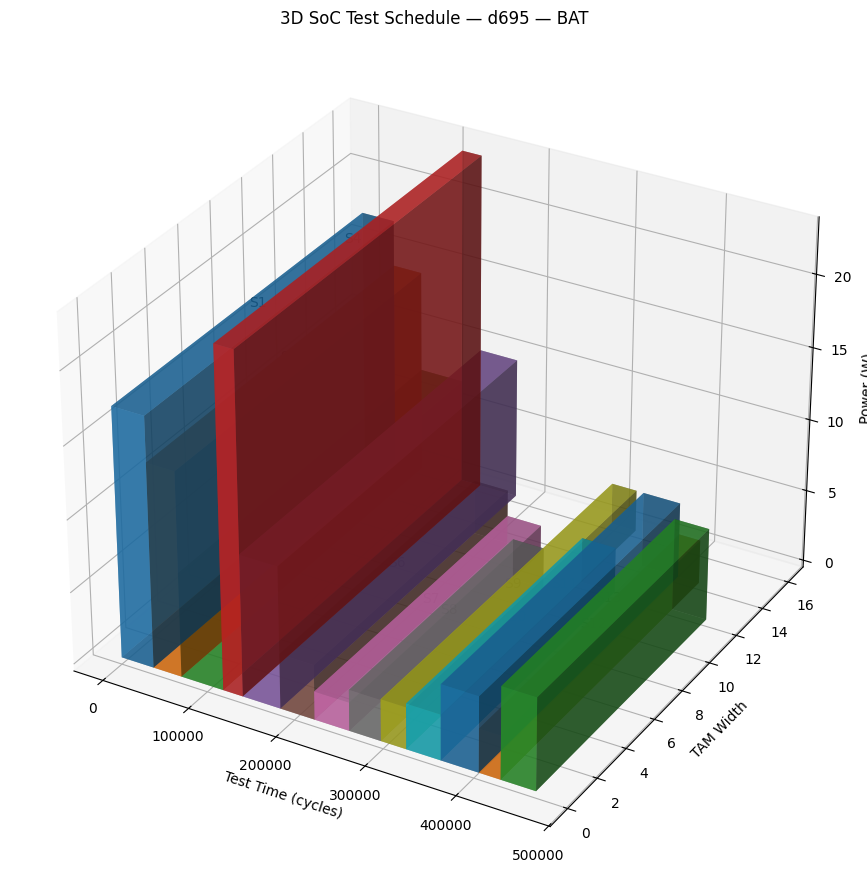

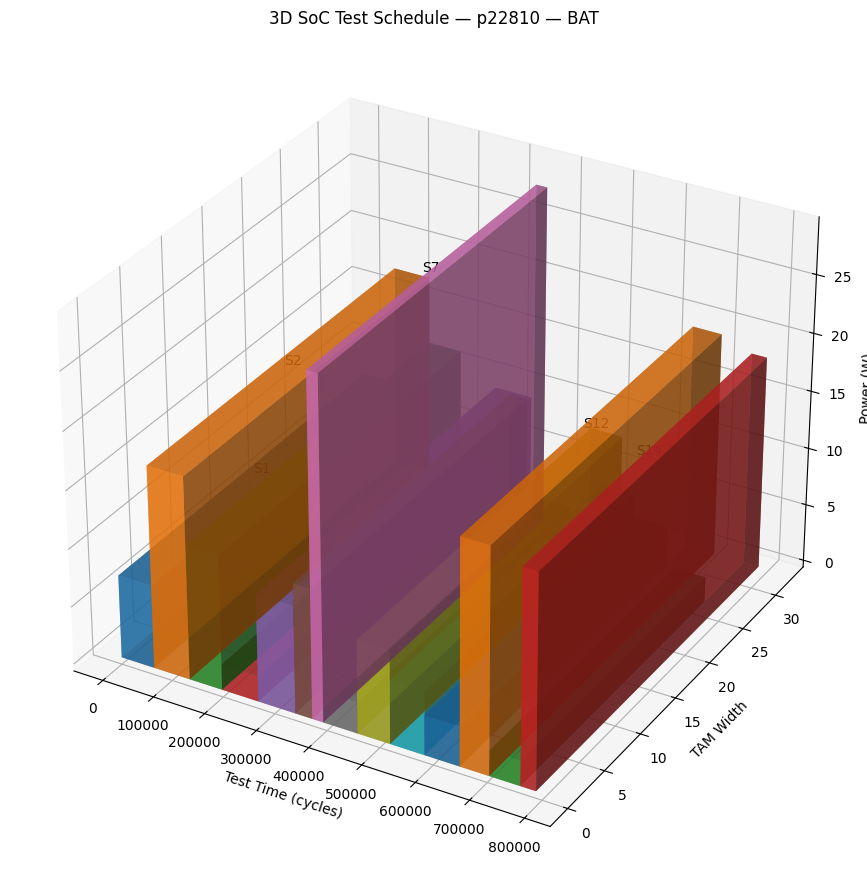

In [26]:
# ============================================================
# CELL 14 — 3D SCHEDULE PLOT
# ============================================================

from mpl_toolkits.mplot3d import Axes3D


def plot_3d_schedule(
    sessions,
    benchmark_name,
    algorithm_name
):

    fig = plt.figure(
        figsize=(14, 9)
    )

    ax = fig.add_subplot(
        111,
        projection="3d"
    )


    # --------------------------------------------------------
    # X = time
    # Y = TAM width
    # Z = power
    # --------------------------------------------------------

    current_time = 0


    for session_id, session in enumerate(
        sessions,
        start=1
    ):

        duration = session[
            "duration"
        ]

        tam = session[
            "tam"
        ]

        power = session[
            "power"
        ]


        # 3D rectangular block
        ax.bar3d(

            current_time,

            0,

            0,

            duration,

            tam,

            power,

            alpha=0.65

        )


        # Label
        ax.text(

            current_time
            +
            duration / 2,

            tam / 2,

            power,

            f"S{session_id}",

            ha="center",

            va="bottom"

        )


        current_time += duration


    ax.set_xlabel(
        "Test Time (cycles)"
    )

    ax.set_ylabel(
        "TAM Width"
    )

    ax.set_zlabel(
        "Power (W)"
    )


    ax.set_title(
        f"3D SoC Test Schedule — "
        f"{benchmark_name} — {algorithm_name}"
    )


    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# Plot selected feasible algorithm
# ------------------------------------------------------------

for benchmark_name, algorithm_name in best_results.items():

    sessions = results_3d[
        benchmark_name
    ][
        algorithm_name
    ][
        "sessions"
    ]


    plot_3d_schedule(

        sessions,

        benchmark_name,

        algorithm_name

    )

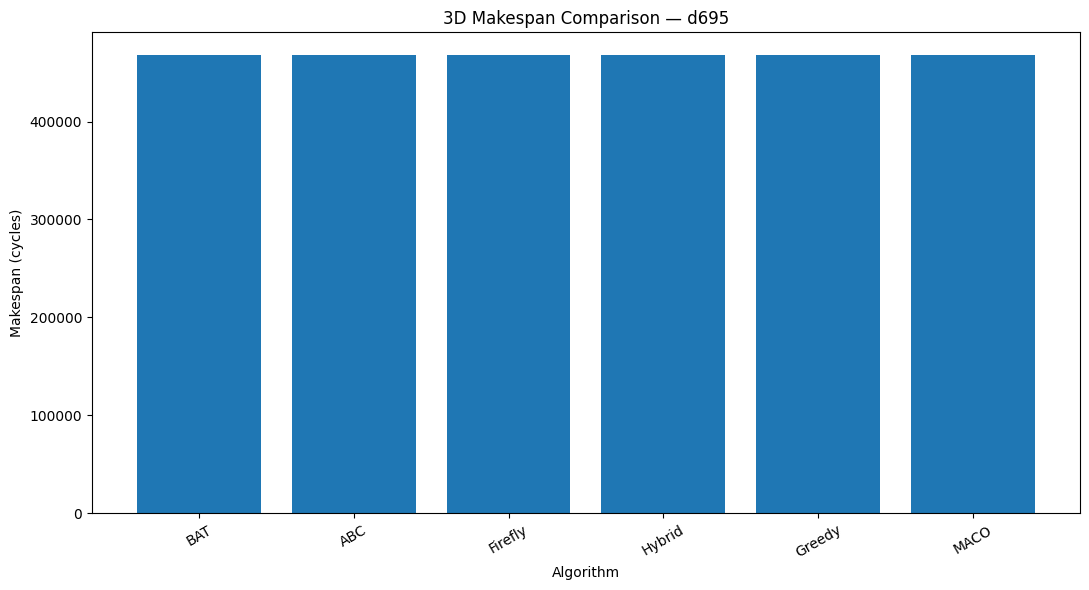

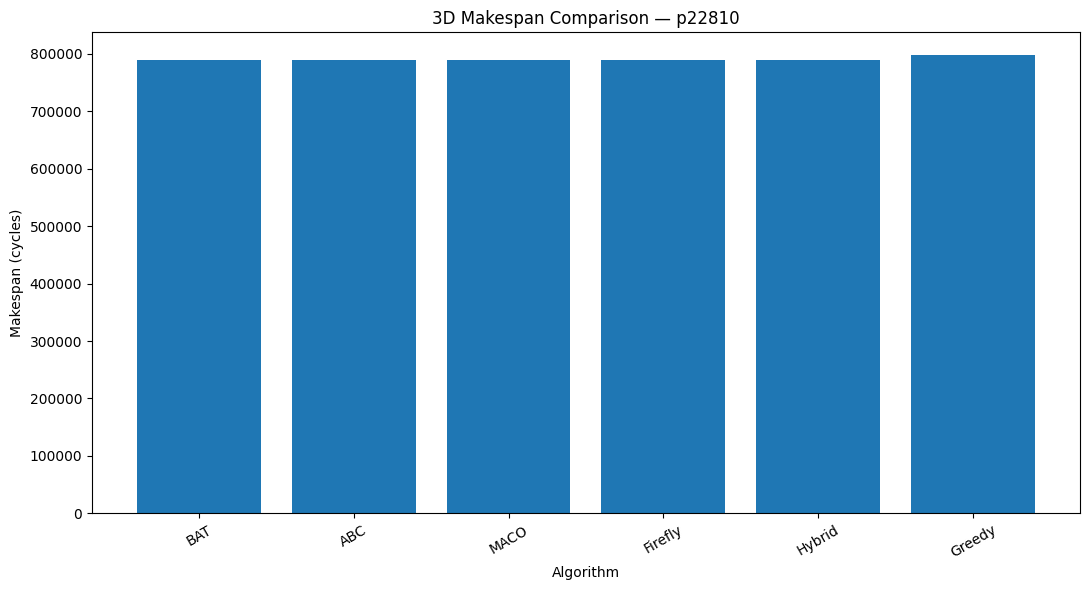

In [27]:
# ============================================================
# CELL 15 — MAKESPAN COMPARISON GRAPH
# ============================================================

for benchmark_name in benchmarks_3d.keys():

    subset = results_3d_df[
        results_3d_df["Benchmark"]
        ==
        benchmark_name
    ].copy()


    subset = subset.sort_values(
        "Makespan (cycles)"
    )


    plt.figure(
        figsize=(11, 6)
    )


    plt.bar(

        subset["Algorithm"],

        subset["Makespan (cycles)"]

    )


    plt.xlabel(
        "Algorithm"
    )

    plt.ylabel(
        "Makespan (cycles)"
    )


    plt.title(
        f"3D Makespan Comparison — "
        f"{benchmark_name}"
    )


    plt.xticks(
        rotation=30
    )


    plt.tight_layout()

    plt.show()

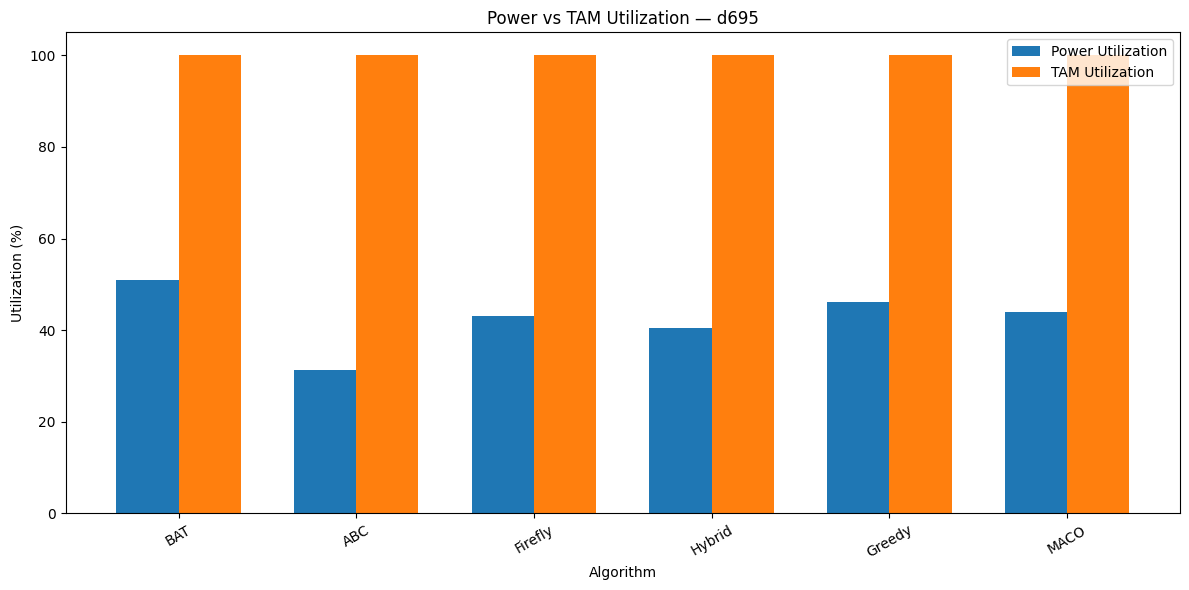

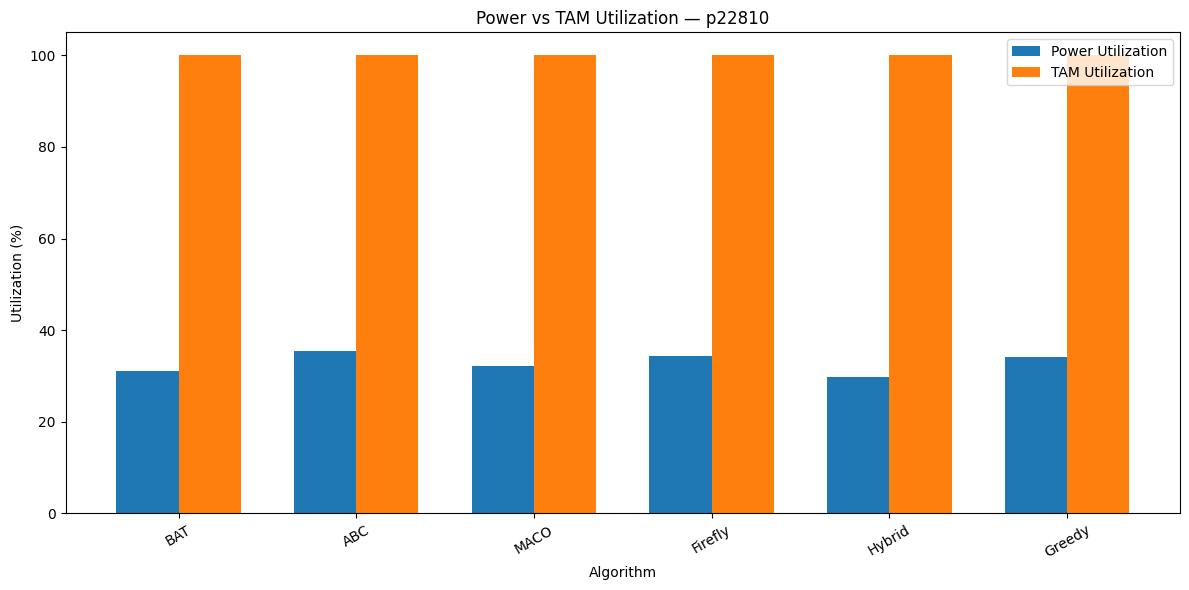

In [28]:
# ============================================================
# CELL 16 — POWER AND TAM UTILIZATION
# ============================================================

for benchmark_name in benchmarks_3d.keys():

    subset = results_3d_df[
        results_3d_df["Benchmark"]
        ==
        benchmark_name
    ]


    x = np.arange(
        len(subset)
    )

    width = 0.35


    plt.figure(
        figsize=(12, 6)
    )


    plt.bar(

        x - width / 2,

        subset["Power Utilization (%)"],

        width,

        label="Power Utilization"

    )


    plt.bar(

        x + width / 2,

        subset["TAM Utilization (%)"],

        width,

        label="TAM Utilization"

    )


    plt.xticks(

        x,

        subset["Algorithm"],

        rotation=30

    )


    plt.ylabel(
        "Utilization (%)"
    )


    plt.xlabel(
        "Algorithm"
    )


    plt.title(
        f"Power vs TAM Utilization — "
        f"{benchmark_name}"
    )


    plt.legend()

    plt.tight_layout()

    plt.show()

In [29]:
# ============================================================
# CELL 17 — DETAILED BEST SCHEDULE
# ============================================================

for benchmark_name, algorithm_name in best_results.items():

    print("\n")
    print("="*100)

    print(
        f"DETAILED SCHEDULE: "
        f"{benchmark_name} — "
        f"{algorithm_name}"
    )

    print("="*100)


    sessions = results_3d[
        benchmark_name
    ][
        algorithm_name
    ][
        "sessions"
    ]


    schedule_rows = []


    for session_id, session in enumerate(
        sessions,
        start=1
    ):

        module_names = [
            m["module_name"]
            for m in session["modules"]
        ]


        schedule_rows.append({

            "Session":
                session_id,

            "Modules":
                ", ".join(
                    module_names
                ),

            "Duration (cycles)":
                session["duration"],

            "Power (W)":
                round(
                    session["power"],
                    3
                ),

            "TAM Width":
                session["tam"]

        })


    schedule_df = pd.DataFrame(
        schedule_rows
    )


    display(
        schedule_df
    )



DETAILED SCHEDULE: d695 — BAT


,Session,Modules,Duration (cycles),Power (W),TAM Width
0,1,"d695_16, d695_5, d695_15",37493,17.257,16
1,2,"d695_7, d695_6",32549,14.122,16
2,3,d695_12,48564,7.198,16
3,4,"d695_21, d695_17, d695_20, d695_3",22420,23.364,16
4,5,"d695_2, d695_19",43071,9.798,16
5,6,d695_1,38923,3.792,13
6,7,d695_13,39140,1.960,13
7,8,d695_22,35312,2.843,11
8,9,"d695_18, d695_9",28174,2.900,16
9,10,d695_11,38146,3.159,12




DETAILED SCHEDULE: p22810 — BAT


,Session,Modules,Duration (cycles),Power (W),TAM Width
0,1,"p22810_4, p22810_25",64501,7.183,32
1,2,"p22810_8, p22810_15",69922,17.445,32
2,3,"p22810_14, p22810_1",63302,11.644,32
3,4,p22810_10,70524,2.194,32
4,5,p22810_26,71163,9.304,32
5,6,"p22810_5, p22810_12",32275,11.215,29
6,7,"p22810_23, p22810_7, p22810_24, p22810_22, p22...",21023,29.232,30
7,8,p22810_17,65341,2.714,29
8,9,"p22810_6, p22810_16",61176,8.067,32
9,10,p22810_19,64440,5.471,29


In [30]:
# ============================================================
# CELL 18 — FINAL SUMMARY
# ============================================================

print("\n")
print("="*100)
print("FINAL 3D SOC TEST SCHEDULING SUMMARY")
print("="*100)


for benchmark_name in benchmarks_3d.keys():

    print(
        f"\nBenchmark: {benchmark_name}"
    )

    print("-"*80)


    subset = results_3d_df[
        results_3d_df["Benchmark"]
        ==
        benchmark_name
    ]


    for _, row in subset.iterrows():

        print(

            f"{row['Algorithm']:<10} | "

            f"Makespan: "
            f"{row['Makespan (cycles)']:>10,} | "

            f"Sessions: "
            f"{row['Sessions']:>2} | "

            f"Peak Power: "
            f"{row['Peak Power (W)']:>7.2f} W | "

            f"Max TAM: "
            f"{row['Max TAM']:>2} | "

            f"Feasible: "
            f"{row['Feasible']}"

        )


    print("-"*80)

    if benchmark_name in best_results:

        print(
            "Minimum-feasible-makespan algorithm: "
            f"{best_results[benchmark_name]}"
        )


print("\n")
print("="*100)
print("3D ANALYSIS COMPLETE ✓")
print("="*100)



FINAL 3D SOC TEST SCHEDULING SUMMARY

Benchmark: d695
--------------------------------------------------------------------------------
BAT        | Makespan:    467,509 | Sessions: 13 | Peak Power:   23.36 W | Max TAM: 16 | Feasible: True
ABC        | Makespan:    467,509 | Sessions: 13 | Peak Power:   14.34 W | Max TAM: 16 | Feasible: True
Firefly    | Makespan:    467,509 | Sessions: 13 | Peak Power:   19.82 W | Max TAM: 16 | Feasible: True
Hybrid     | Makespan:    467,509 | Sessions: 13 | Peak Power:   18.61 W | Max TAM: 16 | Feasible: True
Greedy     | Makespan:    467,648 | Sessions: 13 | Peak Power:   21.20 W | Max TAM: 16 | Feasible: True
MACO       | Makespan:    467,648 | Sessions: 13 | Peak Power:   20.16 W | Max TAM: 16 | Feasible: True
--------------------------------------------------------------------------------
Minimum-feasible-makespan algorithm: BAT

Benchmark: p22810
--------------------------------------------------------------------------------
BAT        | Make